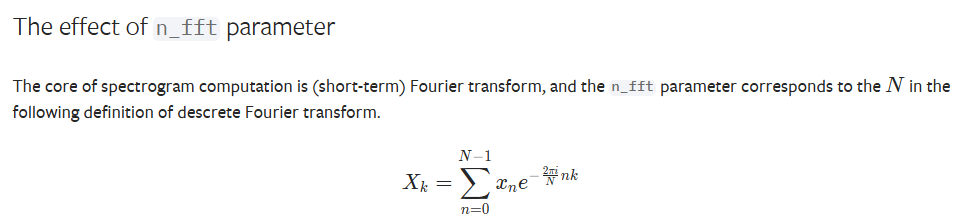

### ⏳Установка зависимостей (Для работы RNNT_NumPy модели и нахождения метрик)

In [3]:
# @title 🌌 Подготовка окружения для Jupyter Notebook (Windows, Python 3.12) на диске E

# Проверка текущего интерпретатора
import sys
print("Python executable:", sys.executable)

# Установка переменных окружения для работы на диске E
import os
os.environ['VIRTUAL_ENV'] = r'E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv'
os.environ['PATH'] = rf"{os.environ['VIRTUAL_ENV']}\Scripts;{os.environ['PATH']}"
os.environ['TEMP'] = 'E:/temp'
os.environ['TMP'] = 'E:/temp'
import tempfile
tempfile.tempdir = 'E:/temp'

# Обновление pip с использованием интерпретатора .venv на диске E
!E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Scripts\python.exe -m pip install --upgrade pip --no-cache-dir --target=E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Lib\site-packages

# Удаление существующего numpy для контроля версии
!E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Scripts\python.exe -m pip uninstall numpy -y -q

# Установка всех необходимых библиотек с явным указанием целевого каталога на диске E
!E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Scripts\python.exe -m pip install \
    nemo_toolkit[asr]==2.3.0 \
    torchaudio==2.5.1 \
    onnxruntime==1.17.3 \
    phonemizer==3.3.0 \
    pymorphy3==2.0.4 \
    sentence-transformers==4.1.0 \
    bert-score==0.3.13 \
    torch==2.5.1 \
    hydra-core==1.3.2 \
    omegaconf==2.3.0 \
    tqdm==4.67.1 \
    jiwer==3.1.0 \
    nltk==3.9.1 \
    torchmetrics==1.7.2 \
    matplotlib==3.10.2 \
    numpy<2.0.0,>=1.22 \
    librosa \
    soundfile \
    scipy \
    --no-cache-dir -f https://download.pytorch.org/whl/torch_stable.html \
    --target=E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Lib\site-packages

# Импорт библиотек
import nemo
import onnxruntime as rt
import phonemizer
import pymorphy3
import sentence_transformers
import bert_score
import torch
import hydra
import omegaconf
import tqdm
import jiwer
import nltk
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import librosa
import soundfile as sf
import scipy
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Union, Type
from torch import Tensor
import torch.nn as nn
from torch.nn import Module
from nemo.collections.asr.models import EncDecHybridRNNTCTCBPEModel
from subprocess import CalledProcessError, run
from collections import defaultdict
from datetime import datetime
import torchaudio.functional as F
import torchaudio.transforms as T
from IPython.display import Audio
import urllib
import json
import tarfile
import logging
import re
import time
import shutil
from tqdm import tqdm
from scipy.ndimage import zoom
from scipy.interpolate import interp1d
from scipy.io import wavfile
from scipy.stats import skew, kurtosis
from matplotlib.gridspec import GridSpec
from matplotlib.axes import Axes
from torch.jit import TracerWarning
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
from torchmetrics.text import (WordErrorRate, CharErrorRate, BLEUScore, WordInfoLost, MatchErrorRate, WordInfoPreserved)

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Инициализация дополнительных ресурсов
nltk.download('punkt')
nltk.download('wordnet')

# Инициализация модели для Semantic Similarity
semantic_model = sentence_transformers.SentenceTransformer('sentence-transformers/LaBSE')

# Инициализация метрик из torchmetrics
wer_metric = WordErrorRate()
cer_metric = CharErrorRate()
wil_metric = WordInfoLost()
mer_metric = MatchErrorRate()
wip_metric = WordInfoPreserved()
bleu_metric = BLEUScore(n_gram=4, weights=(0.25, 0.25, 0.25, 0.25))

# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()

# Проверяем установленные пакеты
!pip list

# Проверка версий
print(f"Nemo version: {nemo.__version__}")
# print(f"Torchaudio version: {torchaudio.__version__}")
print(f"Onnxruntime version: {rt.__version__}")
print(f"Phonemizer version: {phonemizer.__version__}")
print(f"Pymorphy3 version: {pymorphy3.__version__}")
print(f"Sentence Transformers version: {sentence_transformers.__version__}")
print(f"BERT Score version: {bert_score.__version__}")
print(f"Torch version: {torch.__version__}")
print(f"Hydra version: {hydra.__version__}")
print(f"Omegaconf version: {omegaconf.__version__}")
print(f"NLTK version: {nltk.__version__}")
print(f"Torchmetrics version: {torchmetrics.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Librosa version: {librosa.__version__}")
print(f"Soundfile version: {sf.__version__}")
print(f"Scipy version: {scipy.__version__}")

# Проверка совместимости NumPy и PyTorch
try:
    a = torch.randn(5).cpu()
    b = a.numpy()
    print("NumPy is working fine with PyTorch!")
except Exception as e:
    print("NumPy is not working correctly:", e)

# Тестирование импорта NeMo ASR
try:
    from nemo.collections.asr.models import EncDecRNNTModel
    print("NeMo ASR imported successfully!")
except ImportError as e:
    print("NeMo ASR import failed:", e)

# Перезапуск ядра
print("Установите пакеты. Затем перезапустите ядро (Kernel -> Restart) и выполните ячейку снова для проверки.")

# Проверяем установленные пакеты
!pip list

Python executable: E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Scripts\python.exe


"E:\Џа®Ј " ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.
"E:\Џа®Ј " ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.
ЌҐ г¤ Ґвбп ­ ©вЁ гЄ § ­­л© д ©«.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Vladimir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vladimir\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2025-06-09 01:52:55,472 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cpu
2025-06-09 01:52:55,472 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: sentence-transformers/LaBSE
2025-06-09 01:52:59,463 - pymorphy3.opencorpora_dict.wrapper - INFO - Loading dictionaries from E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Lib\site-packages\pymorphy3_dicts_ru\data
2025-06-

Package                   Version
------------------------- ------------------
absl-py                   2.3.0
accelerate                1.7.0
aiohappyeyeballs          2.6.1
aiohttp                   3.12.11
aiosignal                 1.3.2
alembic                   1.16.1
annotated-types           0.7.0
antlr4-python3-runtime    4.9.3
asttokens                 3.0.0
attrs                     25.3.0
audioread                 3.0.1
babel                     2.17.0
bert-score                0.3.13
braceexpand               0.1.7
certifi                   2025.4.26
cffi                      1.17.1
charset-normalizer        3.4.2
click                     8.2.1
cloudpickle               3.1.1
colorama                  0.4.6
coloredlogs               15.0.1
colorlog                  6.9.0
comm                      0.2.2
contourpy                 1.3.2
csvw                      3.5.1
cycler                    0.12.1
cytoolz                   1.0.1
datasets                  3.6.0
DAWG2-Python

### 🎲 Инициализация глобальных параметров

In [4]:
VALID_CMAPS = plt.colormaps()
VALID_INTERPOLATIONS = ['nearest', 'bilinear', 'bicubic', 'spline16', 'spline36', 'hanning', 'hamming', 'hermite', 'kaiser', 'quadric', 'catrom', 'gaussian', 'bessel', 'mitchell', 'sinc', 'lanczos']
VALID_LANGUAGES = ['EN', 'RU']
FORMATS_IMG = ['png', 'jpg', 'jpeg', 'pdf', 'svg']

graphics_dir = "Graphics"

phoneme_cache: Dict[str, List[str]] = {}

@dataclass(frozen=True)
class NeMoConstants:
    AUDIO1_PATH: str = "E:/Прога (вся)/NeuralSpecter/AUDIO_MODELS_DECRYPTION/audio_files/-ot-vinta-bass-bossted.wav"
    AUDIO2_PATH: str =  'E:/Прога (вся)/NeuralSpecter/AUDIO_MODELS_DECRYPTION/audio_files/-blin-zachem-ya-syuda-prishel.wav'
    AUDIO3_PATH: str = 'E:/Прога (вся)/NeuralSpecter/AUDIO_MODELS_DECRYPTION/audio_files/-opa-kogo-to-hlopnuli.wav'
    MODEL_TYPE_RNNT: str = "stt_ru_fastconformer_hybrid_large_pc"
    MODEL_NAME_RNNT: str = "v2_rnnt.onnx"
    DOWNLOAD_CACHE_NEMO: str = "~/.cache/nemo"
    DIRNAME: str = "./onnx_models"
    FLOAT_DIVISOR: float = 32768.0
    DOWNLOAD_CACHE: str = "E:/Прога (вся)/NeuralSpecter/AUDIO_MODELS_DECRYPTION/cache"
    MODEL_TYPE: str = "nvidia/stt_ru_fastconformer_hybrid_large_pc"
    DIRNAME: str = "./onnx_models"
    ENCODER_PATH: str = "onnx_models/encoder-stt_ru_fastconformer_hybrid_large_pc_all.onnx"
    DECODER_PATH: str = "onnx_models/decoder_joint-stt_ru_fastconformer_hybrid_large_pc_all.onnx"
    CUSTOM_ENCODER_PATH: str = "onnx_models/encoder-stt_ru_fastconformer_hybrid_large_pc_RNNT.onnx"
    CUSTOM_DECODER_PATH: str = "onnx_models/decoder_joint-stt_ru_fastconformer_hybrid_large_pc_RNNT.onnx"
    VOCAB_PATH: str = "onnx_models/vocab-stt_ru_fastconformer_hybrid_large_pc_RNNT.txt"
    _URL_DIR: str = "https://huggingface.co/nvidia/stt_ru_fastconformer_hybrid_large_pc/resolve/main/stt_ru_fastconformer_hybrid_large_pc.nemo"

NEMO_CONSTANTS = NeMoConstants()

# Тестовые списки для проверки декодирования по лучу
beam_widths = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
length_penalties = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

@dataclass(frozen=True)
class ConstantsRNNT:
    sample_rate: int = 16_000
    n_fft: int = 400
    win_length: int = 400
    hop_length: int = 160
    n_mels: int = 80
    features: int = 80
    preemph: float = 0.97
    hidden_size: int = 640
    log_zero_guard_value: float = 2 ** -24
    ru_vocab_length: int = 1025

### 📚🗄️ Экспорт в ONNX для Nemo (кастомная модель)

In [5]:
import nemo.collections.asr as nemo_asr

# Аналог _download_file
def _download_file(file_url: str, file_path: str) -> str:
    if os.path.exists(file_path):
        return file_path

    os.makedirs(os.path.dirname(file_path), 
                exist_ok=True)

    with urllib.request.urlopen(file_url) as source, open(file_path, "wb") as output:
        with tqdm(
                total=int(source.info().get("Content-Length", 0)),
                ncols=80,
                unit="iB",
                unit_scale=True,
                unit_divisor=1024,
        ) as loop:
            while True:
                buffer = source.read(8192)
                if not buffer:
                    break
                output.write(buffer)
                loop.update(len(buffer))
    return file_path

# Аналог _download_model для NeMo
def _download_model(model_name: str, 
                    download_root: str
) -> Tuple[str, str]:
    model_url = f"{NEMO_CONSTANTS._URL_DIR}"
    model_path = os.path.join(download_root, f"{model_name}.nemo")
    return model_name, _download_file(model_url, model_path)

# Аналог load_model для NeMo
def load_nemo_model(model_name: str, 
                    device: str = "cpu",
                    download_root: Optional[str] = None
) -> nemo_asr.models.ASRModel:
    if download_root is None:
        download_root = os.path.expanduser(NEMO_CONSTANTS.DOWNLOAD_CACHE)
    else:
        download_root = os.path.expanduser(NEMO_CONSTANTS.DOWNLOAD_CACHE_NEMO)

    # Проверяем наличие модели
    model_path = os.path.join(download_root, f"{model_name}.nemo")

    # Always check available models
    print("Проверка доступных моделей:")
    available_models = nemo_asr.models.ASRModel.list_available_models()
    print("Available models:", available_models)

    if os.path.exists(model_path):
        file_size = os.path.getsize(model_path)
        print(f"Файл найден: {model_path}, размер: {file_size} байт")
        if file_size == 0:
            print("Файл пустой, удаляем и попробуем скачать заново")
            os.remove(model_path)
    else:
        print(f"Файл не найден: {model_path}, будет выполнен новый запрос")
        _download_model(model_name, download_root)

    # Загружаем модель
    try:
        model = nemo_asr.models.ASRModel.from_pretrained(f"nvidia/{model_name}")
        logging.info(f"Модель {model_name} успешно загружена")
    except Exception as e:
        print(f"Ошибка при загрузке модели из файла: {e}")
        raise
    return model.to(device)

def export_nemo_to_onnx(
        model_name: str = NEMO_CONSTANTS.MODEL_TYPE,
        onnx_dir: str = NEMO_CONSTANTS.DIRNAME,
        device: str = "cpu",
        download_root: Optional[str] = None,
        decoder_types: Optional[List[str]] = None
) -> Tuple[nemo_asr.models.ASRModel, str, str]:
    # По умолчанию экспортируем только RNNT декодер (как в вашем случае)
    if decoder_types is None:
        decoder_types = ["rnnt"]

    # Создаём директорию для ONNX
    onnx_dir = Path(onnx_dir)
    onnx_dir.mkdir(exist_ok=True, 
                   parents=True)

    # Загружаем модель
    model = load_nemo_model(model_name=model_name, 
                            device=device, 
                            download_root=download_root)

    # Определяем дефолтные значения из AudioToMelSpectrogramPreprocessor
    default_preprocessor_params = {
        "sample_rate": 16000,
        "window_size": 0.02,
        "window_stride": 0.01,
        "n_window_size": None,
        "n_window_stride": None,
        "window": "hann",
        "normalize": "per_feature",
        "n_fft": None,
        "preemph": 0.97,
        "features": 64,
        "lowfreq": 0,
        "highfreq": None,
        "log": True,
        "log_zero_guard_type": "add",
        "log_zero_guard_value": 2**-24,
        "dither": 1e-5,
        "pad_to": 16,
        "frame_splicing": 1,
        "exact_pad": False,
        "pad_value": 0,
        "mag_power": 2.0,
        "rng": None,
        "nb_augmentation_prob": 0.0,
        "nb_max_freq": 4000,
        "use_torchaudio": False,
        "mel_norm": "slaney",
        "stft_exact_pad": False,
        "stft_conv": False
    }

    # Извлекаем параметры препроцессора из конфигурации модели
    preprocessor_params = {}
    if hasattr(model, "cfg") and hasattr(model.cfg, "preprocessor"):
        print("\nПараметры препроцессора из model.cfg.preprocessor:")
        cfg_preprocessor = dict(model.cfg.preprocessor)
        # Список всех возможных параметров на основе дефолтов AudioToMelSpectrogramPreprocessor
        expected_params = list(default_preprocessor_params.keys())
        for param in expected_params:
            if param in cfg_preprocessor:
                value = cfg_preprocessor[param]
                preprocessor_params[param] = value
                print(f"{param}: {value}")
            else:
                # Используем дефолтное значение, если параметр не указан
                value = default_preprocessor_params[param]
                preprocessor_params[param] = value
                print(f"{param}: {value} (дефолтное значение)")
    else:
        print("\nПараметры препроцессора из model.cfg.preprocessor: (не доступны)")
        raise AttributeError("Model configuration or preprocessor config not found")

    # Сохраняем параметры препроцессора в JSON
    params_path = onnx_dir / f"preprocessor_params_{model_name}.json"
    with open(params_path, "w", encoding="utf-8") as f:
        json.dump(preprocessor_params, f, indent=4, ensure_ascii=False)
    print(f"\nПараметры препроцессора сохранены в: {params_path}")

    # Извлекаем и сохраняем вокабуляр
    if hasattr(model, "tokenizer"):
        vocab = list(model.tokenizer.vocab)
        vocab_dict = {token: idx for idx, token in enumerate(vocab)}
        blank_idx = vocab_dict.get("<blank>", len(vocab))  # Fallback if <blank> is not in vocab
        vocab.append("<blank>")  # Ensure blank token is included
        vocab_dict["<blank>"] = blank_idx
    else:
        raise AttributeError("Model does not have a tokenizer attribute to access vocabulary")

    vocab_path = onnx_dir / f"vocab-{model_name}.txt"
    if not vocab_path.exists():
        vocab_path = os.path.join(NEMO_CONSTANTS.DIRNAME, "vocab-stt_ru_fastconformer_hybrid_large_pc_RNNT.txt")
        os.makedirs(NEMO_CONSTANTS.DIRNAME, exist_ok=True)
        with open(vocab_path, "w", encoding="utf-8") as f:
            for token, idx in vocab_dict.items():
                f.write(f"{token} {idx}\n")
        print(f"Вокабуляр сохранён в: {vocab_path}")

    # Экспортируем модель для каждого декодера
    for decoder_type in decoder_types:
        print(f"Экспортируем модель с декодером: {decoder_type}")
        model.set_export_config({"decoder_type": decoder_type})
        onnx_path = str(onnx_dir / f"{model_name}_{decoder_type}.onnx")
        model.export(onnx_path)
        print(f"Модель '{model_name}' с декодером '{decoder_type}' успешно экспортирована в {onnx_path}")

    logging.info(f"Экспорт модели в ONNX завершён. Вокабуляр доступен в {vocab_path}")
    return model, vocab_path, params_path

### 📚🗄️ Экспорт в ONNX (оригинальная модель)

In [ ]:
try:
    # Загружаем модель
    print("Загрузка модели...")
    asr_model = nemo_asr.models.EncDecHybridRNNTCTCBPEModel.from_pretrained(
        model_name="nvidia/stt_ru_fastconformer_hybrid_large_pc"
    )
    print(f"Модель успешно загружена. Тип токенизатора: {type(asr_model.tokenizer.tokenizer)}")

    # Определяем директорию и пути для экспорта
    output_dir = Path("onnx_models")
    output_dir.mkdir(exist_ok=True)
    onnx_path = output_dir / "stt_ru_fastconformer_hybrid_large_pc_all.onnx"
    vocab_path = output_dir / "vocab-stt_ru_fastconformer_hybrid_large_pc_all.txt"

    # Экспортируем модель в ONNX
    print("Сохранение модели...")
    asr_model.export(str(onnx_path))
    print(f"Модель успешно экспортирована в {onnx_path}")

    # Сохраняем словарь токенов
    print("Сохранение словаря...")
    try:
        with vocab_path.open("wt", encoding="utf-8") as f:
            for i, token in enumerate([*asr_model.tokenizer.vocab, "<blk>"]):
                f.write(f"{token} {i}\n")
        print(f"Вокабуляр сохранён в {vocab_path}")
    except IOError as e:
        print(f"Ошибка при сохранении словаря: {e}")
        raise

except Exception as e:
    print(f"Произошла ошибка: {e}")
    raise

print("ok")

### 🧨 Загрузка в ONNX своей функцией

In [6]:
#@title 🌌Подготовка окружения
# Путь к аудиофайлу (прописаны в константах - NEMO_CONSTANTS)
audio_path = "audio_files/20250404_174500.wav"
ground_truth = "мне необходимо вам рассказать следующую историю о своей жизни чем четче я говорю тем лучше результат я получу"

# ground_truth_rnnt = "мне необходимо вам рассказать следующую историю о своей жизни чем четче я говорю тем лучший результат я получу"

if not os.path.exists(audio_path):
    raise FileNotFoundError(f"Файл не найден по пути: {audio_path}")

In [ ]:
model, vocab_path, params_path = export_nemo_to_onnx(
    model_name=NEMO_CONSTANTS.MODEL_TYPE_RNNT,
    onnx_dir=NEMO_CONSTANTS.DIRNAME,
    device="cpu",
    decoder_types=["rnnt"]
)
logging.info(f"Экспорт модели в ONNX завершён. Вокабуляр доступен в {vocab_path}")

#### 🎧Проверка исходного аудио

In [ ]:
Audio(audio_path, rate=ConstantsRNNT.sample_rate)

### 💻 Класс расчёта метрик

In [7]:
def compute_rouge_manual(reference: str,
                         hypothesis: str
) -> Dict[str, float]:
    """
    Compute ROUGE-1, ROUGE-2, and ROUGE-L manually.

    Parameters
    ----------
    reference : str
        Reference text (ground truth).
    hypothesis : str
        Hypothesis text (transcription).

    Returns
    -------
    Dict[str, float]
        Dictionary with ROUGE-1, ROUGE-2, and ROUGE-L F1-scores.
    """
    ref_tokens = reference.split()
    hyp_tokens = hypothesis.split()

    # ROUGE-1 (униграммы)
    ref_unigrams = set(ref_tokens)
    hyp_unigrams = set(hyp_tokens)
    overlapping_unigrams = len(ref_unigrams & hyp_unigrams)
    precision_1 = overlapping_unigrams / len(hyp_tokens) if hyp_tokens else 0
    recall_1 = overlapping_unigrams / len(ref_tokens) if ref_tokens else 0
    f1_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

    # ROUGE-2 (биграммы)
    ref_bigrams = set(tuple(ref_tokens[i:i+2]) for i in range(len(ref_tokens)-1))
    hyp_bigrams = set(tuple(hyp_tokens[i:i+2]) for i in range(len(hyp_tokens)-1))
    overlapping_bigrams = len(ref_bigrams & hyp_bigrams)
    precision_2 = overlapping_bigrams / len(hyp_bigrams) if hyp_bigrams else 0
    recall_2 = overlapping_bigrams / len(ref_bigrams) if ref_bigrams else 0
    f1_2 = 2 * (precision_2 * recall_2) / (precision_2 + recall_2) if (precision_2 + recall_2) > 0 else 0

    # ROUGE-L (наибольшая общая подпоследовательность)
    def lcs(X, Y):
        m, n = len(X), len(Y)
        L = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            for j in range(n + 1):
                if i == 0 or j == 0:
                    L[i][j] = 0
                elif X[i-1] == Y[j-1]:
                    L[i][j] = L[i-1][j-1] + 1
                else:
                    L[i][j] = max(L[i-1][j], L[i][j-1])
        return L[m][n]

    lcs_length = lcs(ref_tokens, hyp_tokens)
    precision_l = lcs_length / len(hyp_tokens) if hyp_tokens else 0
    recall_l = lcs_length / len(ref_tokens) if ref_tokens else 0
    f1_l = 2 * (precision_l * recall_l) / (precision_l + recall_l) if (precision_l + recall_l) > 0 else 0

    return {
        "ROUGE-1": f1_1,
        "ROUGE-2": f1_2,
        "ROUGE-L": f1_l
    }

def normalize_text(text: str, remove_punctuation: bool = True) -> str:
    """
    Normalize text by optionally removing punctuation and extra spaces.

    Parameters
    ----------
    text : str
        Input text to normalize.
    remove_punctuation : bool, optional
        Whether to remove punctuation. Defaults to True.

    Returns
    -------
    str
        Normalized text (lowercase, optional no punctuation, single spaces).
    """
    if remove_punctuation:
        text = re.sub(r'[^\w\s]', '', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def round_metrics(metrics: Dict[str, float],
                  precision: int = 14
) -> Dict[str, float]:
    """
    Round numerical values in the metrics dictionary to the specified precision.

    Parameters
    ----------
    metrics : Dict[str, float]
        Dictionary of metrics.
    precision : int, optional
        Number of decimal places to round to. Defaults to 14.

    Returns
    -------
    Dict[str, float]
        Dictionary with rounded values.
    """
    rounded_metrics = {}
    for key, value in metrics.items():
        if isinstance(value, (int, float)):
            rounded_metrics[key] = round(value, precision)
        else:
            rounded_metrics[key] = value
    return rounded_metrics

def log_metrics_to_json(metrics: Dict[str, float],
                        ground_truth: str,
                        transcription: str,
                        total_log_prob: float,
                        beam_width: int,
                        length_penalty: float,
                        flag: str,
                        filename: str = "metrics_log.json"
) -> None:
    """
    Log metrics to a JSON file as a list of entries, including context and timestamp.

    Parameters
    ----------
    metrics : Dict[str, float]
        Dictionary of computed metrics.
    ground_truth : str
        Ground truth text.
    transcription : str
        Transcription text.
    total_log_prob: float
        Total log probability.
    beam_width: int
        Beam width.
    length_penalty: float
        Length penalty.
    flag: str
        Shows which method of decode is currently using
        Options: "greedy" - greedy decoding,
                 "beam" - decode by using a beam search
    filename : str, optional
        Path to the JSON log file. Defaults to "metrics_log.json".
    """
    global entry
    if flag == "greedy":
        entry = {
            "timestamp": datetime.now().isoformat(),
            "flag": flag,
            "ground_truth": ground_truth,
            "transcription": transcription,
            "total_log_prob": total_log_prob,
            "metrics": round_metrics(metrics),
        }
    elif flag == "beam":
        entry = {
            "timestamp": datetime.now().isoformat(),
            "flag": flag,
            "ground_truth": ground_truth,
            "transcription": transcription,
            "total_log_prob": total_log_prob,
            "beam_width": beam_width,
            "length_penalty": length_penalty,
            "metrics": round_metrics(metrics),
        }
    if os.path.exists(filename):
        try:
            with open(filename,
                      "r",
                      encoding="utf-8") as file:
                data = json.load(file)
                if not isinstance(data, list):
                    data = [data]
        except (json.JSONDecodeError, FileNotFoundError) as e:
            print(f"Error reading {filename}: {e}. Starting with an empty list!")
            data = []
    else:
        data = []

    data.append(entry)
    try:
        with open(filename,
                  "w",
                  encoding="utf-8") as file:
            json.dump(data,
                      file,
                      indent=4,
                      ensure_ascii=False)
    except Exception as e:
        print(f"Error writing to {filename}: {e}")

def return_metrics(transcription: str, ground_truth: str = None, metrics: Dict[str, float] = None,
                  compute_semantic: bool = True, total_log_prob: float = 0.0, beam_width: int = 3,
                  length_penalty: float = 1.0, flag: str = "greedy", normalize: bool = True) -> Dict[str, float]:
    """
    Compute various evaluation metrics for comparing transcription with ground truth.

    Parameters
    ----------
    transcription : str
        Predicted transcription text.
    ground_truth : str, optional
        Reference (ground truth) text.
    metrics : Dict[str, float], optional
        Dictionary to store computed metrics. If None, a new dictionary is created.
    compute_semantic : bool, optional
        Flag that indicates whether to compute Semantic Similarity. Defaults to True.
    total_log_prob : float, optional
        Total log probability. Defaults to 0.0.
    beam_width : int, optional
        Number of beams to keep at each step. Defaults to 3.
    length_penalty : float, optional
        Length penalty to apply during beam selection. Defaults to 1.0.
    flag : str, optional
        Shows which method of decode is currently using. Options: "greedy" or "beam". Defaults to "greedy".
    normalize : bool, optional
        Whether to normalize text (remove punctuation, lowercase). Defaults to True.

    Returns
    -------
    Dict[str, float]
        Dictionary containing computed metrics:
        - WER, CER, MER, WIL, WIP, RIL (from jiwer)
        - WER_torchmetrics, CER_torchmetrics, WIL_torchmetrics, MER_torchmetrics, WIP_torchmetrics (from torchmetrics)
        - BLEU, BLEU_torchmetrics
        - ROUGE-1, ROUGE-2, ROUGE-L
        - Semantic Similarity (cosine similarity between embeddings)
        - PER (Phoneme Error Rate)
        - METEOR
        - BERTScore

    Raises
    ------
    ValueError
        If ground truth or transcription is empty or not a string.

    Notes
    -----
    - Some metrics (e.g., PER, Semantic Similarity) may return None if computation fails.
    - Texts are optionally normalized before computing metrics.
    - Metrics are logged to 'metrics_log.json'.
    """
    # Проверка и преобразование типов данных
    if not isinstance(ground_truth, str):
        if ground_truth is None:
            ground_truth = ""
        else:
            ground_truth = str(ground_truth)
    if not isinstance(transcription, str):
        transcription = str(transcription)

    if not ground_truth.strip() or not transcription.strip():
        raise ValueError("Ground truth and transcription must be provided and not empty.")

    if metrics is None:
        metrics = {}

    # Сохранение оригинальных текстов для метрик, где нормализация нежелательна
    ground_truth_orig = ground_truth
    transcription_orig = transcription

    # Нормализация текста, если включена
    if normalize:
        ground_truth = normalize_text(ground_truth, remove_punctuation=True)
        transcription = normalize_text(transcription, remove_punctuation=True)
        print(f"Ground Truth (normalized): '{ground_truth}'")
        print(f"Transcription (normalized): '{transcription}'")
    else:
        print(f"Ground Truth (original): '{ground_truth_orig}'")
        print(f"Transcription (original): '{transcription_orig}'")

    # Метрики из jiwer
    metrics["WER"] = jiwer.wer(ground_truth, transcription)
    metrics["CER"] = jiwer.cer(ground_truth, transcription)
    metrics["MER"] = jiwer.mer(ground_truth, transcription)
    metrics["WIL"] = jiwer.wil(ground_truth, transcription)
    metrics["WIP"] = jiwer.wip(ground_truth, transcription)
    metrics["RIL"] = 1 - metrics["WIP"]

    # Метрики из torchmetrics
    metrics["WER_torchmetrics"] = wer_metric([transcription], [ground_truth]).item()
    metrics["CER_torchmetrics"] = cer_metric([transcription], [ground_truth]).item()
    metrics["WIL_torchmetrics"] = wil_metric([transcription], [ground_truth]).item()
    metrics["MER_torchmetrics"] = mer_metric([transcription], [ground_truth]).item()
    metrics["WIP_torchmetrics"] = wip_metric([transcription], [ground_truth]).item()
    metrics["RIL_torchmetrics"] = 1 - metrics["WIP_torchmetrics"]

    # BLEU
    if len(transcription.split()) < 4:
        metrics["BLEU"] = 0.0
        metrics["BLEU_torchmetrics"] = 0.0
        print("Warning: Transcription too short for meaningful BLEU score")
    else:
        metrics["BLEU"] = sentence_bleu([ground_truth.split()], transcription.split(), weights=(0.25, 0.25, 0.25, 0.25))
        metrics["BLEU_torchmetrics"] = bleu_metric([transcription], [[ground_truth]]).item()

    # ROUGE
    rouge_scores = compute_rouge_manual(ground_truth, transcription)
    metrics.update(rouge_scores)

    # Semantic Similarity
    if compute_semantic:
        try:
            semantic_model = SentenceTransformer('sentence-transformers/LaBSE')
            ref_embedding = semantic_model.encode(ground_truth_orig, convert_to_tensor=True)
            hyp_embedding = semantic_model.encode(transcription_orig, convert_to_tensor=True)
            metrics["Semantic Similarity"] = util.cos_sim(ref_embedding, hyp_embedding).item()
            if metrics["Semantic Similarity"] < 0.5:
                print("Warning: Low semantic similarity, texts may have different meanings")
        except Exception as e:
            print(f"Error computing Semantic Similarity: {e}")
            metrics["Semantic Similarity"] = None
    else:
        metrics["Semantic Similarity"] = None

    # Phoneme Error Rate (PER)
    try:
        phonemized_ref = phonemize(ground_truth_orig, language='ru', backend='espeak')
        phonemized_hyp = phonemize(transcription_orig, language='ru', backend='espeak')
        metrics["PER"] = jiwer.wer(phonemized_ref, phonemized_hyp)
    except Exception as e:
        print(f"Error computing PER: {e}")
        metrics["PER"] = None

    # METEOR
    try:
        metrics["METEOR"] = meteor_score([ground_truth_orig.split()], transcription_orig.split())
    except Exception as e:
        print(f"Error computing METEOR: {e}")
        metrics["METEOR"] = None

    # BERTScore
    try:
        P, R, F1 = bert_score.score([transcription_orig], [ground_truth_orig], lang="ru", verbose=False)
        metrics["BERTScore"] = F1.mean().item()
    except Exception as e:
        print(f"Error computing BERTScore: {e}")
        metrics["BERTScore"] = None

    # Логирование метрик в файл
    log_metrics_to_json(metrics=metrics, ground_truth=ground_truth_orig, transcription=transcription_orig,
                       total_log_prob=total_log_prob, beam_width=beam_width, length_penalty=length_penalty, flag=flag)

    print("Metrics:")
    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.15f}")
        else:
            print(f"{metric}: Not computed due to error")
    return metrics


# Использование WER (Word Error Rate)
# WER = (S + D + I) / N (CSR модель)
# WER = S / (N1 = H + S) = 1 - H/N1 (IWR модель)
# Смысл: измерение процента ошибок на уровне слов: сравнение эталонного текста с предсказанным
# S - количество замен (substitutions)
# D - количество удвлений (deletions)
# I - количество вставок (insertations)
# H - количество попадений (hits)
# N  - общее число слов в эталонном тексте = H + S + D - количество входных слов
# N1 = H + S - число пар-совпадений (matched I/O word pairs)

# Использование CER (Character Error Rate)
# CER = (Sc + Dc + Ic) / N
# Смысл: Сравнение эталонного и предсказанного текста посимвольно

# Использование MER (Match Error Rate)
# MER = N_not_matched / N_total = (S + D + I) / (N = H + S + D + I) = 1 - H / N_total
# Смысл: Показ доли слов, не совпавших с эталоном
# N_not_matched - число несовпавших слов
# N_total - общее число слов в эталоне

# Использование WIL (Word Information Lost)
# WIL = 1 - H^2 / (N1 * N2) = 1 - WIP = I(x,y) / H(Y) (на выравнивании слов и штрафах за ошибки)
# Смысл: Метрика для оценки потери информации на уровне слов с учётом совпадений подстрок
# H >> S + D + I
# N1 - число входных слов, N2 - число выходных слов

# Использование WIP (Word Information Preserved)
# WIP = H^2 / (N1 * N2)
# Смысл: Метрика для оценки сохранённой информации на уровне слов
# H - количество попаданий (hits)
# N1 - число слов в эталоне (ground truth), N2 - число слов в предсказании (transcription)
# Значение: от 0 до 1, где 1 означает, что вся информация сохранена (H = N1 = N2)

# Использование RIL (Reference Information Lost)
# RIL = 1 - WIP = 1 - H^2 / (N1 * N2)
# Смысл: Метрика для оценки потерянной информации из эталона (ground truth) при предсказании
# Значение: от 0 до 1, где 0 означает, что вся информация из эталона сохранена, а 1 — что вся информация потеряна
# RIL дополняет WIP: если WIP высок (много информации сохранено), то RIL низкий, и наоборот

# Использование BLEU (Bilingual Evaluation Understudy)
# BLEU = BP * exp(sum(n=1, N) w(n)*log(p(n)))
# Смысл: Метрика машинного перевода для измерения точности n-грамм (последовательностей слов) в предсказании по сравнению с эталоном
# BP - штраф за длину
# p(n) - точность n-грамм
# w(n) - веса

# Использование ROUGE (Recall-Oriented Understudy for Gisting Evaluation)
# ROUGE-N = (пересечение n-грамм между эталоном и предсказанием) / (число n-грамм в эталоне)
# ROUGE-L = (длина наибольшей общей подпоследовательности) / (длина эталона)
# Смысл: Метрика суммаризации текстов, измеряет пересечение n-грамм и общих подпоследовательностей

# Использование PER (Phenomene Error Rate)
# PER = (S(p) + D(p) + I(p)) / N(p) (пока не используется)
# Смысл: Метрика для оценки ошибок на уровне фонем (звуков): преобразование текстов в фонетическую транскрипцию
# S(p) - количество замен фонем
# D(p) - количество удаления фонем
# I(p) - количество вставок фонем
# N(p) - число фонем в эталоне

# Использование семантической близости (Semantic Similarity)
# Смысл: Использует методы embeddings (BERT, FastText) для оценки семантической близости между эталоном и предсказанием
# Значение: Косинусное сходство между эмбеддингами (от 0 до 1)

# Использование METEOR (Metric for Evaluation of Translation with Explicit ORdering)
# METEOR = P * R / ((1 - α) * R + α * P) * (1 - γ * (frag_score)^β)
# Смысл: Метрика для оценки качества перевода или текста с учётом синонимии, морфологии и порядка слов
# P - точность (precision): доля слов в предсказании, совпадающих с эталоном (с учётом синонимов)
# R - полнота (recall): доля слов из эталона, найденных в предсказании
# α - весовой коэффициент для балансировки между P и R (обычно 0.9)
# frag_score - штраф за фрагментацию: m / u, где m - число "кусков" совпадающих слов, u - число совпавших слов
# γ - вес штрафа за фрагментацию (обычно 0.5)
# β - степень штрафа за фрагментацию (обычно 3.0)
# Значение: от 0 до 1, где 1 означает идеальное совпадение

# Использование BERTScore
# BERTScore = max(cos_sim(emb_pred_i, emb_ref_j)) для каждого токена i в предсказании и j в эталоне
# Смысл: Метрика для оценки семантической близости текста с использованием эмбеддингов BERT
# emb_pred_i - эмбеддинг i-го токена предсказания (получается из BERT)
# emb_ref_j - эмбеддинг j-го токена эталона (получается из BERT)
# cos_sim - косинусное сходство между эмбеддингами токенов
# P - средняя точность: усреднённое максимальное сходство для токенов предсказания
# R - средняя полнота: усреднённое максимальное сходство для токенов эталона
# F1 - гармоническое среднее между P и R
# Значение: от 0 до 1, где 1 означает полное семантическое совпадение



### 🪫 NumPy реализация NVIDIA Nemo модели с кастомным препроцессором

In [8]:
class NumPyPreprocessor:
    def __init__(self,
                 graphics_create: bool = False,
                 window: str = "hann",
                 center: bool = True,
                 mel_filterbank_type: str = "complex"):
        """Initialize the NumPy-based audio preprocessor."""
        self.sample_rate = ConstantsRNNT.sample_rate
        self.n_fft = ConstantsRNNT.n_fft
        self.win_length = ConstantsRNNT.win_length
        self.hop_length = ConstantsRNNT.hop_length
        self.n_mels = ConstantsRNNT.n_mels
        self.preemph = ConstantsRNNT.preemph
        self.log_zero_guard_value = ConstantsRNNT.log_zero_guard_value
        self.graphics_create = graphics_create
        self.window = window
        self.center = center
        self.mel_filterbank_type = mel_filterbank_type

    def stft_numpy(self,
                   signal: np.ndarray,
                   window: str = "hann"
    ) -> np.ndarray:
        """Compute the Short-Time Fourier Transform (STFT) of an audio signal.

        Parameters
        ----------
        signal : np.ndarray
            Input audio signal, shape [time].
        n_fft : int, optional
            Number of FFT points (default: 400).
        hop_length : int, optional
            Hop length between frames in samples (default: 160).
        win_length : int, optional
            Window length in samples (default: 400).
        window : str, optional
            Window type, supports 'hann', 'hamming', 'blackman' (default: 'hann').
        center : bool, optional
            If True, pads the signal to center frames (default: True).

        Returns
        -------
        np.ndarray
            STFT matrix, shape [n_fft // 2 + 1, n_frames], dtype complex128.

        Notes
        -----
        - Supports 'hann', 'hamming', and 'blackman' window types.
        - Applies padding to center frames when center=True.
        - Returns only positive frequency components.
        """
        if self.window == 'hann':
            win = np.hanning(self.win_length)
        elif self.window == 'hamming':
            win = np.hamming(self.win_length)
        elif self.window == 'blackman':
            win = np.blackman(self.win_length)
        else:
            win = np.ones(self.win_length)

        # Padding
        if self.center:
            pad_amount = self.n_fft // 2
            signal = np.pad(signal,
                            pad_amount,
                            mode='reflect')

        # Количество фреймов
        n_frames = 1 + (len(signal) - self.n_fft) // self.hop_length

        # Инициализация результата
        stft_matrix = np.zeros((self.n_fft // 2 + 1, n_frames),
                               dtype=np.complex128)

        # Вычисление STFT
        for i in range(n_frames):
            start = i * self.hop_length
            end = start + self.n_fft

            if end <= len(signal):
                frame = signal[start:end]

                # Применяем окно
                if len(frame) == self.win_length:
                    frame = frame * win
                elif len(frame) == self.n_fft and self.win_length != self.n_fft:
                    # Дополняем или обрезаем окно
                    if self.win_length < self.n_fft:
                        win_padded = np.pad(win,
                                            (0, self.n_fft - self.win_length),
                                            mode='constant')
                    else:
                        win_padded = win[:self.n_fft]
                    frame = frame * win_padded
                else:
                    frame = frame * win

                # FFT
                fft_frame = np.fft.fft(frame,
                                       n=self.n_fft)
                stft_matrix[:, i] = fft_frame[:self.n_fft // 2 + 1]

        return stft_matrix

    def create_mel_filterbank_torch_compatible(self) -> np.ndarray:
        """Create a Mel filterbank compatible with torchaudio.MelScale.
        Returns
        -------
        np.ndarray
            Mel filterbank matrix, shape [n_mels, n_fft // 2 + 1], dtype float32.

        Notes
        -----
        - Uses the HTK Mel scale formula as in torchaudio.
        - Normalizes filters using the 'slaney' method for area normalization.
        """
        fmax = self.sample_rate / 2.0
        n_freqs = self.n_fft // 2 + 1

        # Mel scale conversion (HTK=False, как в torchaudio по умолчанию)
        def hz_to_mel(hz):
            return 2595.0 * np.log10(1.0 + hz / 700.0)

        def mel_to_hz(mel):
            return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

        # Создаем точки в mel шкале
        mel_min = hz_to_mel(0.0)
        mel_max = hz_to_mel(fmax)
        mel_points = np.linspace(mel_min, mel_max, self.n_mels + 2)
        hz_points = mel_to_hz(mel_points)

        # Частоты для FFT bins
        fft_freqs = np.linspace(0, fmax, n_freqs)

        # Создаем фильтр банк
        filterbank = np.zeros((self.n_mels, n_freqs))
        for m in range(self.n_mels):
            left = hz_points[m]
            center = hz_points[m + 1]
            right = hz_points[m + 2]
            for k in range(n_freqs):
                freq = fft_freqs[k]
                if left <= freq <= center and center != left:
                    filterbank[m, k] = (freq - left) / (center - left)
                elif center < freq <= right and right != center:
                    filterbank[m, k] = (right - freq) / (right - center)

        # Нормализация
        # Нормализуем каждый фильтр по его площади
        enorm = 2.0 / (hz_points[2:self.n_mels + 2] - hz_points[:self.n_mels])
        filterbank *= enorm[:, np.newaxis]
        return filterbank.astype(np.float32)

    def _create_mel_filterbank_simple(self) -> np.ndarray:
        """Create a Mel filterbank compatible with torchaudio.MelScale.

        Returns
        -------
        np.ndarray
            Mel filterbank matrix, shape [n_mels, n_fft // 2 + 1], dtype float32.

        Notes
        -----
        - Uses a simplified Mel scale formula with linear spacing.
        - Normalizes each filter to sum to 1 for consistency.
        """
        n_freqs = int(ConstantsRNNT.n_fft // 2 + 1)
        f_min, f_max = 0.0, ConstantsRNNT.sample_rate / 2.0

        # Используем формулу mel scale как в torchaudio
        mel_min = 1125.0 * np.log1p(f_min / 700.0)
        mel_max = 1125.0 * np.log1p(f_max / 700.0)
        mel_points = np.linspace(mel_min, mel_max, ConstantsRNNT.n_mels + 2)
        freq_points = 700.0 * (np.expm1(mel_points / 1125.0))

        # Создаем банк фильтров
        fb = np.zeros((ConstantsRNNT.n_mels, n_freqs))
        freqs = np.linspace(0, f_max, n_freqs)

        for m in range(ConstantsRNNT.n_mels):
            f_left = freq_points[m]
            f_center = freq_points[m + 1]
            f_right = freq_points[m + 2]

            for f in range(n_freqs):
                if f_left <= freqs[f] <= f_center and f_center != f_left:
                    fb[m, f] = (freqs[f] - f_left) / (f_center - f_left)
                elif f_center < freqs[f] <= f_right and f_right != f_center:
                    fb[m, f] = (f_right - freqs[f]) / (f_right - f_center)

        fb = fb / (np.sum(fb,
                          axis=1,
                          keepdims=True) + 1e-10)

        return fb.astype(np.float32)

    def extract_features(self, input_signal: np.ndarray, length: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Extract log-mel spectrogram features from the input audio signal.

        Parameters
        ----------
        input_signal : np.ndarray
            Input audio signal, shape [batch, channels, time].
        length : np.ndarray
            Lengths of the input audio signals, shape [batch].

        Returns
        -------
        Tuple[np.ndarray, np.ndarray]
            A tuple containing:
            - Log-mel spectrogram features, shape [batch, n_mels, time_frames].
            - Output lengths after feature extraction, shape [batch].
        """
        global mel_fb
        print(f"input_signal shape: {input_signal.shape}, min: {np.min(input_signal)}, max: {np.max(input_signal)}")
        if np.isnan(input_signal).any() or np.isinf(input_signal).any():
            print("Warning: input_signal contains NaN or Inf values!")

        mean = np.mean(input_signal)
        std = np.std(input_signal)
        if std == 0:
            std = 1e-6
        print(f"Mean before CMVN: {mean}, Std before CMVN: {std}")
        input_signal = (input_signal - mean) / (std + 1e-6)

        if ConstantsRNNT.preemph != 0.0:
            batch_size, channels, time = input_signal.shape
            for b in range(batch_size):
                for c in range(channels):
                    signal = input_signal[b, c]
                    preemph_signal = np.concatenate([signal[:1], signal[1:] - ConstantsRNNT.preemph * signal[:-1]])
                    input_signal[b, c] = preemph_signal

        batch_size, channels, time = input_signal.shape
        num_frames = int(np.floor(time / ConstantsRNNT.hop_length) + 1)
        print(f"batch_size: {batch_size}, channels: {channels}, time: {time}, num_frames: {num_frames}")

        if num_frames <= 0:
            raise ValueError(
                f"Signal length ({time}) is too short for STFT with n_fft={ConstantsRNNT.n_fft} and hop_length={ConstantsRNNT.hop_length}. "
                f"Need at least {ConstantsRNNT.n_fft} samples."
            )

        if self.mel_filterbank_type == "complex":
            mel_fb = self.create_mel_filterbank_torch_compatible()
        elif self.mel_filterbank_type == "simple":
            mel_fb = self._create_mel_filterbank_simple()
        mel_specs = []

        for b in range(batch_size):
            for c in range(channels):
                signal = input_signal[b, c]
                # Выбираем окно в зависимости от self.window
                if self.window == 'hamming':
                    stft_result = self.stft_numpy(signal,
                                                  window=self.window)
                elif self.window == 'blackman':
                    stft_result = self.stft_numpy(signal,
                                                  window=self.window)
                else:
                    stft_result = self.stft_numpy(signal,
                                                  window=self.window)

                power_spec = np.abs(stft_result) ** 2
                if power_spec.shape[1] > num_frames:
                    power_spec = power_spec[:, :num_frames]
                elif power_spec.shape[1] < num_frames:
                    power_spec = np.pad(power_spec,
                                        ((0, 0),
                                         (0, num_frames - power_spec.shape[1])),
                                        mode='constant',
                                        constant_values=0)
                print(f"Power spectrum shape: {power_spec.shape}, min: {np.min(power_spec)}, max: {np.max(power_spec)}")
                np.save("power_spec_numpy.npy", power_spec)
                mel_spec = np.dot(mel_fb, power_spec)
                print(f"Mel spec shape: {mel_spec.shape}, min: {np.min(mel_spec)}, max: {np.max(mel_spec)}")
                np.save("mel_spec_numpy.npy", mel_spec)
                mel_specs.append(mel_spec)

        mel_spectrogram = np.stack(mel_specs, axis=0).reshape(batch_size,
                                                              channels,
                                                              ConstantsRNNT.n_mels,
                                                              num_frames)
        print(f"Mel spectrogram shape: {mel_spectrogram.shape}")
        print(f"Melspec NumPy: min={np.min(mel_spectrogram)}, max={np.max(mel_spectrogram)}")

        log_mel_spec = np.log(mel_spectrogram + ConstantsRNNT.log_zero_guard_value)
        print(f"Log mel spec NumPy shape: {log_mel_spec.shape}, min: {np.min(log_mel_spec)}, max: {np.max(log_mel_spec)}")
        np.save("mel_spec_numpy_raw.npy", log_mel_spec)

        mean = np.mean(log_mel_spec,
                       axis=3,
                       keepdims=True)
        std = np.std(log_mel_spec,
                     axis=3,
                     keepdims=True)
        print(f"After CMVN: mean={mean}, std={std}")
        log_mel_spec = (log_mel_spec - mean) / (std + 1e-6)
        print(f"After CMVN log_mel_spec: mean={np.mean(log_mel_spec)}, std={np.std(log_mel_spec)}")
        np.save("mel_spec_numpy_cmvn.npy", log_mel_spec)

        if channels == 1:
            log_mel_spec = log_mel_spec.squeeze(1)

        features = log_mel_spec.astype(np.float32)
        features_len = np.array([num_frames],
                                dtype=np.int64)
         # Добавляем проверку тензоров
        print(f"Features shape: {features.shape}")
        print(f"Features length: {features_len}")
        print("Features shape:", features.shape)
        print("Features dtype:", features.dtype)
        print("Features (Custom RNNT model: первые несколько значений):", features[0, :, :5])
        print(f"After CMVN: mean={np.mean(features)}, std={np.std(features)}")

        if self.graphics_create:
            if not os.path.exists(graphics_dir):
                os.makedirs(graphics_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{graphics_dir}/mel_spectrogram_NumPy_{timestamp}.png"
            plt.figure(figsize=(10, 4))
            plt.imshow(features[0],
                       aspect="auto",
                       origin="lower",
                       interpolation="nearest")
            plt.colorbar(label="Normalized Log Mel Energy")
            plt.title("Mel-Spectrogram (After CMVN)")
            plt.xlabel("Time Frames")
            plt.ylabel("Mel Frequency Bins")
            plt.tight_layout()
            plt.savefig(filename)
            plt.close()

        return features, features_len

def load_vocab(vocab_path: str) -> List[str]:
    """Load vocabulary from a file into a list of tokens.

    Parameters
    ----------
    vocab_path : str
        Path to the vocabulary file containing token-index pairs or single tokens.

    Returns
    -------
    List[str]
        List of vocabulary tokens, padded with "<pad>" up to 1025 entries.

    Notes
    -----
    - Supports files with either 'token index' pairs or single tokens per line.
    - Pads the vocabulary with "<pad>" if the length is less than 1025.
    """
    vocab = []
    with open(vocab_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                token, idx = parts
                idx = int(idx)
                while len(vocab) <= idx:
                    vocab.append("")
                vocab[idx] = token
            elif len(parts) == 1:
                vocab.append(parts[0])
    while len(vocab) < ConstantsRNNT.ru_vocab_length:
        vocab.append("<pad>")
    return vocab

class RnntASRNumPy:
    def __init__(self,
                 encoder_path: str,
                 decoder_joint_path: str,
                 vocab_path: str,
                 graphics_create: bool = False,
                 window: str = "hann",
                 center: bool = True,
                 mel_filterbank_type: str = "complex"
    ) -> None:
        """Initialize the RNN-T ASR model with ONNX encoder and decoder-joint components.

        Parameters
        ----------
        encoder_path : str
            Path to the ONNX encoder model file.
        decoder_joint_path : str
            Path to the ONNX decoder-joint model file.

        Notes
        -----
        - Sets up model inputs and outputs based on ONNX session metadata.
        - Loads vocabulary and initializes token indices for special tokens.
        """
        self.features = ConstantsRNNT.features
        self.hidden_size = ConstantsRNNT.hidden_size
        self._encoder = rt.InferenceSession(encoder_path, 
                                            providers=["CPUExecutionProvider"])
        self._decoder_joint = rt.InferenceSession(decoder_joint_path, providers=["CPUExecutionProvider"])
        self.vocab = load_vocab(vocab_path)
        self._setup_token_indices()
        self._print_model_info()
        self.graphics_create = graphics_create
        self.window = window
        self.center = center
        self.mel_filterbank_type = mel_filterbank_type

        self._encoder_input_name = self._encoder.get_inputs()[0].name
        self._encoder_length_name = self._encoder.get_inputs()[1].name
        self._decoder_input_name = self._decoder_joint.get_inputs()[0].name
        self._decoder_prev_token_name = self._decoder_joint.get_inputs()[1].name
        self._decoder_state_name = self._decoder_joint.get_inputs()[2].name
        self._decoder_output_name = self._decoder_joint.get_outputs()[0].name
        self._decoder_state_out_name = self._decoder_joint.get_outputs()[1].name

        print("Decoder joint inputs:")
        for inp in self._decoder_joint.get_inputs():
            print(f"Name: {inp.name}, Shape: {inp.shape}, Type: {inp.type}")

    def _setup_token_indices(self) -> None:
        """Set up indices for special tokens in the vocabulary.

        Notes
        -----
        - Identifies indices for blank, unknown, and padding tokens.
        - Populates a set of tokens to filter during decoding.
        """
        self._blank_idx = self.vocab.index("<blk>") if "<blk>" in self.vocab else ConstantsRNNT.ru_vocab_length - 1
        self._unk_idx = self.vocab.index("<unk>") if "<unk>" in self.vocab else ConstantsRNNT.ru_vocab_length - 1
        self._blk_idx = self._blank_idx
        self._pad_idx = self.vocab.index("<pad>") if "<pad>" in self.vocab else ConstantsRNNT.ru_vocab_length - 1
        self._max_vocab_idx = len(self.vocab) - 1
        self._tokens_to_filter = {self._blank_idx, self._unk_idx, self._blk_idx, self._pad_idx}
        for i in range(self._max_vocab_idx + 1, len(self.vocab)):
            self._tokens_to_filter.add(i)

    def _print_model_info(self) -> None:
        """Print detailed information about the loaded vocabulary and token indices.

        Notes
        -----
        - Displays vocabulary size and sample tokens for debugging.
        """
        print(f"Loaded vocabulary with {len(self.vocab)} tokens")
        print(f"First 10 tokens: {self.vocab[:10]}")
        print(f"Last 10 tokens: {self.vocab[-10:]}")
        print(f"Blank index: {self._blank_idx} ('{self.vocab[self._blank_idx]}')")
        print(f"UNK index: {self._unk_idx} ('{self.vocab[self._unk_idx]}')")
        print(f"Pad index: {self._pad_idx} ('{self.vocab[self._pad_idx]}')")
        print(f"Max vocab index: {self._max_vocab_idx}")

    def _print_tensor_info(self,
                           title: str,
                           tensors: List[rt.NodeArg]
    ) -> None:
        """Print tensor metadata for debugging purposes.

        Parameters
        ----------
        title : str
            Title to describe the tensor group.
        tensors : List[rt.NodeArg]
            List of ONNX tensor metadata objects.

        Notes
        -----
        - Displays name, shape, and type for each tensor.
        """
        print(f"{title}:")
        for tensor in tensors:
            print(f"Name: {tensor.name}, Shape: {tensor.shape}")

    def out_len(self,
                input_lengths: np.ndarray
    ) -> np.ndarray:
        """Calculate output length after feature extraction based on input audio length.

        Parameters
        ----------
        input_lengths : np.ndarray
            Input audio lengths, shape [batch].

        Returns
        -------
        np.ndarray
            Output lengths after applying hop length, shape [batch].

        Notes
        -----
        - Uses floor division with hop_length (160) to compute frame count.
        """
        return np.floor_divide(input_lengths, ConstantsRNNT.hop_length) + 1

    def extract_features(self,
                         input_signal: np.ndarray,
                         length: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Extract log-mel spectrogram features using the NumPyPreprocessor.

        Parameters
        ----------
        input_signal : np.ndarray
            Input audio signal, shape [batch, channels, time].
        length : np.ndarray
            Lengths of the input audio signals, shape [batch].

        Returns
        -------
        Tuple[np.ndarray, np.ndarray]
            A tuple containing:
            - Log-mel spectrogram features, shape [batch, n_mels, time_frames].
            - Output lengths after feature extraction, shape [batch].
        """
        preprocessor = NumPyPreprocessor(self.graphics_create,
                                         self.window,
                                         self.center,
                                         self.mel_filterbank_type)
        return preprocessor.extract_features(input_signal, length)

    def _encode(self,
                features: np.ndarray,
                features_lens: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Encode input features using the ONNX encoder model.

        Parameters
        ----------
        features : np.ndarray
            Log-mel spectrogram features, shape [batch, features, time_frames].
        features_lens : np.ndarray
            Lengths of the feature sequences, shape [batch].

        Returns
        -------
        Tuple[np.ndarray, np.ndarray]
            A tuple containing:
            - Encoded output, shape [batch, hidden_size, time_frames].
            - Output lengths after encoding, shape [batch].

        Notes
        -----
        - Runs inference using the ONNX encoder session.
        """
        encoder_out, encoder_out_lens = self._encoder.run(
            ["outputs", "encoded_lengths"],
            {"audio_signal": features, "length": features_lens}
        )
        return encoder_out, encoder_out_lens

    def _decode(self,
                prev_tokens: List[int],
                prev_state: Tuple[np.ndarray, np.ndarray],
                encoder_out: np.ndarray
    ) -> Tuple[np.ndarray, int, Tuple[np.ndarray, np.ndarray]]:
        """Decode a single step using the ONNX decoder-joint model.

        Parameters
        ----------
        prev_tokens : List[int]
            Previous decoded token sequence.
        prev_state : Tuple[np.ndarray, np.ndarray]
            Previous decoder states, shape [(1, 1, hidden_size), (1, 1, hidden_size)].
        encoder_out : np.ndarray
            Encoded output for the current time step, shape [batch, hidden_size, 1].

        Returns
        -------
        Tuple[np.ndarray, int, Tuple[np.ndarray, np.ndarray]]
            A tuple containing:
            - Logits for the current step, shape [vocab_size].
            - Placeholder return value (currently -1).
            - Updated decoder states.

        Notes
        -----
        - Uses the previous token or blank token as input.
        - Runs inference using the ONNX decoder-joint session.
        - Prints debug information for logits.
        """
        prev_token = self._blank_idx if not prev_tokens else prev_tokens[-1]
        inputs = {
            "encoder_outputs": encoder_out.astype(np.float32),
            "targets": np.array([[prev_token]], dtype=np.int32),
            "target_length": np.array([1], dtype=np.int32),
            "input_states_1": prev_state[0],
            "input_states_2": prev_state[1],
        }
        outputs = self._decoder_joint.run(
            ["outputs", "output_states_1", "output_states_2"],
            inputs
        )
        logits = np.squeeze(outputs[0])
        print(f"Debug: logits shape={logits.shape}, min={logits.min()}, max={logits.max()}")
        return logits, -1, (outputs[1], outputs[2])

    def decode_rnnt_greedy_improved(self,
                                    encoder_output: np.ndarray,
                                    ground_truth: str = None,
                                    state_init: str = "zero",
                                    clean_transcription: bool = True
    ) -> Tuple[str, Dict[str, float], List[int]]:
        """Perform greedy decoding to transcribe encoded audio output.

        Parameters
        ----------
        encoder_output : np.ndarray
            Encoded output from the encoder, shape [batch, hidden_size, time_frames].
        ground_truth : str, optional
            Ground truth transcription for metric computation.
        state_init : str, optional
            Initialization method for decoder states ('zero' or 'random').

        Returns
        -------
        Tuple[str, Dict[str, float], List[int]]
            A tuple containing:
            - Transcribed text.
            - Metrics dictionary if ground truth is provided.
            - List of timestamps corresponding to decoded tokens.

        Notes
        -----
        - Applies blank and repeat penalties during decoding.
        - Uses `_postprocess_uncleaned` for final text cleanup.
        """
        max_len = encoder_output.shape[2]
        print(f"Starting improved greedy decoding with {max_len} time frames")
        if state_init == "random":
            state = (np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32),
                     np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32))
        else:
            state = (np.zeros((1, 1, self.hidden_size), dtype=np.float32),
                     np.zeros((1, 1, self.hidden_size), dtype=np.float32))
        hyp = []
        total_log_prob = 0.0
        blank_penalty = -0.5
        repeat_penalty = 0.1
        for t in range(max_len):
            current_encoder_out = encoder_output[:, :, t:t + 1]
            logits, _, state = self._decode(hyp, state, current_encoder_out)
            logits = logits.copy()
            if self._blank_idx < len(logits):
                logits[self._blank_idx] += blank_penalty
            if self._pad_idx < len(logits):
                logits[self._pad_idx] -= 5.0
            logits = logits - np.max(logits)
            probs = np.exp(logits) / (np.sum(np.exp(logits)))

            if hyp and hyp[-1] != self._blank_idx:
                probs[hyp[-1]] *= repeat_penalty

            next_token = np.argmax(probs).item()
            if next_token != self._blank_idx and (not hyp or next_token != hyp[-1]):
                hyp.append(next_token)
                # Добавляем логарифм вероятности для выбранного токена
                total_log_prob += np.log(probs[next_token])

            if t % 5 == 0:
                token_str = self.vocab[next_token] if next_token < len(self.vocab) else 'OUT_OF_VOCAB'
                print(f"Step {t}: token={next_token}('{token_str}'), prob={probs[next_token]:.3f}")

        if clean_transcription == False:
            text = self._postprocess_uncleaned(hyp, "greedy")
        else:
            text = self._postprocess_cleaned(hyp, "greedy")
        metrics = {}
        if ground_truth and text:
            metrics = return_metrics(transcription=text,
                                     ground_truth=ground_truth,
                                     metrics=metrics,
                                     total_log_prob=total_log_prob,
                                     flag="greedy")
        return text, metrics, [t for t in range(len(hyp))]

    def decode_rnnt_beam_search_fixed(self,
                                      encoder_output: np.ndarray,
                                      vocab: List[str],
                                      blank_idx: int,
                                      beam_width: int = 8,
                                      length_penalty: float = 0.7,
                                      ground_truth: str = None,
                                      max_steps: int = 1000,
                                      min_tokens: int = 18,
                                      state_init: str = "zero",
                                      clean_transcription: bool = True
    ) -> Tuple[str, Dict[str, float], List[int]]:
        """Perform fixed beam search decoding to transcribe encoded audio output.

        Parameters
        ----------
        encoder_output : np.ndarray
            Encoded output from the encoder, shape [batch, hidden_size, time_frames].
        vocab : List[str]
            Vocabulary list for token mapping.
        blank_idx : int
            Index of the blank token in the vocabulary.
        beam_width : int, optional
            Number of beams to maintain during search (default: 8).
        length_penalty : float, optional
            Penalty factor for sequence length (default: 0.7).
        ground_truth : str, optional
            Ground truth transcription for metric computation.
        max_steps : int, optional
            Maximum number of decoding steps (default: 1000).
        min_tokens : int, optional
            Minimum number of tokens to continue search (default: 18).
        state_init : str, optional
            Initialization method for decoder states ('zero' or 'random').

        Returns
        -------
        Tuple[str, Dict[str, float], List[int]]
            A tuple containing:
            - Transcribed text.
            - Metrics dictionary if ground truth is provided.
            - List of timestamps corresponding to decoded tokens.

        Notes
        -----
        - Implements beam search with temperature scaling and penalties.
        - Prunes beams based on unique sequences and scores.
        - Uses `_postprocess_uncleaned` for final text cleanup.
        """
        if encoder_output.shape[0] != 1:
            raise ValueError(f"Expected batch_size=1, got {encoder_output.shape[0]}")

        batch_size, hidden_size, time_frames = encoder_output.shape
        print(f"Starting fixed beam search: beam_width={beam_width}, time_frames={time_frames}")

        if state_init == "random":
            state = (np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32),
                     np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32))
        else:
            state = (np.zeros((1, 1, self.hidden_size), dtype=np.float32),
                     np.zeros((1, 1, self.hidden_size), dtype=np.float32))

        beams = [(tuple(), 0.0, state, [], 0, 0, [])]
        temperature = 0.8
        blank_penalty = -2.0
        repeat_penalty = 0.05
        step = 0
        max_iterations = min(time_frames * 4, max_steps)

        while step < max_iterations:
            new_beams = []

            for seq, score, (state1, state2), prev_tokens, curr_t, token_count, timestamps in beams:
                if curr_t >= time_frames:
                    new_beams.append((seq, score, (state1, state2), prev_tokens, curr_t, token_count, timestamps))
                    continue

                current_encoder_out = encoder_output[:, :, curr_t:curr_t + 1]
                if current_encoder_out.shape[2] == 0:
                    print(f"Warning: encoder_output_t is empty at t={curr_t}, skipping this beam")
                    new_beams.append((seq, score, (state1, state2), prev_tokens, curr_t + 1, token_count, timestamps))
                    continue

                logits, _, (new_state1, new_state2) = self._decode(prev_tokens, (state1, state2), current_encoder_out)
                logits_t = logits.copy()

                if logits_t.size == 0:
                    print(f"Warning: logits are empty at t={curr_t}, skipping this beam")
                    new_beams.append((seq, score, (state1, state2), prev_tokens, curr_t + 1, token_count, timestamps))
                    continue

                print(f"DEBUG: t={curr_t}, raw logits_t for blank {self._blank_idx}: {logits_t[self._blank_idx]:.4f}")
                non_blank_logits = np.delete(logits_t,
                                             self._blank_idx)
                non_blank_vocab_indices = np.delete(np.arange(len(self.vocab)), self._blank_idx)
                k_val = min(5, len(non_blank_logits))
                top_5_raw_indices_in_non_blank_array = np.argsort(non_blank_logits)[-k_val:]
                top_5_raw_indices = non_blank_vocab_indices[top_5_raw_indices_in_non_blank_array]
                print("DEBUG: t={curr_t}, top 5 raw non-blank logits: " +
                      ", ".join([f"{self.vocab[idx]}:{logits_t[idx]:.4f}" for idx in top_5_raw_indices]))

                if blank_idx < len(logits_t):
                    logits_t[blank_idx] += blank_penalty
                if self._pad_idx < len(logits_t):
                    logits_t[self._pad_idx] -= 5.0

                if temperature != 1.0:
                    logits_t = logits_t / temperature
                logits_t = logits_t - np.max(logits_t)
                exp_logits = np.exp(logits_t)
                probs = exp_logits / (np.sum(exp_logits) + 1e-12)

                if len(seq) > 0:
                    last_token = seq[-1]
                    if last_token != blank_idx:
                        probs[last_token] *= repeat_penalty

                top_indices = np.argsort(probs)[-beam_width * 2:][::-1]
                for token in top_indices:
                    prob = probs[token]
                    new_score = score + np.log(prob + 1e-12)
                    new_seq = seq + (token,)
                    new_timestamps = timestamps + [curr_t]
                    new_count = token_count + (1 if token != blank_idx else 0)
                    new_prev_tokens = prev_tokens + [token]

                    new_beams.append((new_seq, new_score, (new_state1, new_state2), new_prev_tokens, curr_t + 1,
                                      new_count, new_timestamps))

            unique_beams = {}
            for beam in new_beams:
                key = (beam[0], tuple(beam[3]))
                if key not in unique_beams or beam[1] > unique_beams[key][1]:
                    unique_beams[key] = beam

            beams = sorted(list(unique_beams.values()), 
                           key=lambda x: x[1], 
                           reverse=True)[:beam_width]
            step += 1

            if all(beam[4] >= time_frames for beam in beams) and step > min_tokens:
                print(f"All beams completed at step {step}")
                break

        if not beams:
            return "", {}, []

        best_beam = beams[0]
        best_seq, best_score, _, _, _, token_count, timestamps = best_beam

        print(f"Best raw sequence (token IDs): {best_seq}")
        print(f"Mapped raw sequence: {[vocab[idx] for idx in best_seq if idx < len(vocab)]}")

        if clean_transcription == False:
            text = self._postprocess_uncleaned(list(best_seq), "beam")
        else:
            text = self._postprocess_cleaned(list(best_seq), "beam")

        print(f"Fixed Beam Search completed:")
        print(f"  Transcription: '{text}'")
        print(f"  Log probability: {best_score:.6f}")
        normalized_score = best_score / (max(1, token_count) ** length_penalty) if token_count > 0 else best_score
        print(f"  Normalized score: {normalized_score:.6f}")
        print(f"  Total tokens: {token_count}")
        print(f"  Steps: {step}")

        metrics = {}
        if ground_truth and text:
            metrics = return_metrics(
                transcription=text,
                ground_truth=ground_truth,
                metrics=metrics,
                total_log_prob=best_score,
                beam_width=beam_width,
                length_penalty=length_penalty,
                flag="beam"
            )

        return text, metrics, timestamps

    def _postprocess_uncleaned(self,
                              decoded_ids: List[int],
                              flag: str = "greedy"
    ) -> str:
        """Postprocess decoded token IDs into a cleaned text string.

        Parameters
        ----------
        decoded_ids : List[int]
            List of decoded token IDs from the model.
        flag : str, optional
            Flag to indicate decoding method ('greedy' or beam') for logging.

        Returns
        -------
        str
            Cleaned and formatted transcription text.

        Notes
        -----
        - Filters out special tokens and applies word deduplication.
        - Normalizes whitespace and preserves double characters.
        - Capitalizes the first letter for readability.
        """
        valid_tokens = [self.vocab[tok_id] for tok_id in decoded_ids if
                        tok_id < len(self.vocab) and tok_id not in {self._blank_idx, self._pad_idx}]
        text = "".join(valid_tokens).replace("▁", " ").strip()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)

        words = text.split()
        cleaned_words = []
        last_word = None
        for word in words:
            if word and (not last_word or word.lower() != last_word.lower() or len(word) <= 2):
                cleaned_words.append(word)
                last_word = word

        text = " ".join(cleaned_words).strip()
        text = re.sub(r'(?<=\s)[.,!?]+$', '', text).strip()
        text = text[0].upper() + text[1:] if text else text

        if flag == "greedy":
            print(f"Final transcription (Improved Greedy Decoding): '{text}'")
        elif flag == "beam":
            print(f"Final transcription (Improved Beam Search): '{text}'")
        return text

    def _postprocess_cleaned(self,
                                decoded_ids: List[int],
                                flag: str = "greedy"
    ) -> str:
        """Alternative postprocessing method for decoded token IDs.

        Parameters
        ----------
        decoded_ids : List[int]
            List of decoded token IDs from the model.
        flag : str, optional
            Flag to indicate decoding method ('greedy' or 'beam') for logging.

        Returns
        -------
        str
            Cleaned and formatted transcription text.

        Notes
        -----
        - Similar to `_postprocess_uncleaned` but with stricter punctuation removal.
        - Preserves double characters and normalizes whitespace.
        """
        valid_tokens = [self.vocab[tok_id] for tok_id in decoded_ids if
                        tok_id < len(self.vocab) and tok_id not in {self._blank_idx, self._pad_idx}]
        text = "".join(valid_tokens).replace("▁", " ").strip()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)

        text = re.sub(r'[.,!?;:()"\'-]', '', text).lower()

        words = text.split()
        cleaned_words = []
        last_word = None
        for word in words:
            if word and (not last_word or word != last_word or len(word) <= 2):
                cleaned_words.append(word)
                last_word = word

        text = " ".join(cleaned_words).strip()

        if flag == "greedy":
            print(f"Final transcription (Improved Greedy Decoding): '{text}'")
        elif flag == "beam":
            print(f"Final transcription (Improved Beam Search): '{text}'")
        return text

    def _get_log_probs(self,
                       full_encoder_out: np.ndarray,
                       t: int,
                       prev_token: int,
                       state: tuple
    ) -> Tuple[np.ndarray, tuple]:
        """Compute log probabilities for a single decoding step.

        Parameters
        ----------
        full_encoder_out : np.ndarray
            Full encoded output, shape [batch, hidden_size, time_frames].
        t : int
            Current time step index.
        prev_token : int
            Previous token ID.
        state : tuple
            Previous decoder states, shape [(1, 1, hidden_size), (1, 1, hidden_size)].

        Returns
        -------
        Tuple[np.ndarray, tuple]
            A tuple containing:
            - Log probabilities, shape [vocab_size].
            - Updated decoder states.

        Notes
        -----
        - Slices encoder output for the current time step.
        - Runs inference using the ONNX decoder-joint session.
        - Normalizes logits to compute log probabilities safely.
        """
        decoder_input = np.array([[prev_token]],
                                 dtype=np.int32)

        inputs = {
            "encoder_outputs": full_encoder_out[:, :, t:t + 1].astype(np.float32),
            "targets": decoder_input,
            "target_length": np.array([1],
                                      dtype=np.int32),
            "input_states_1": state[0],
            "input_states_2": state[1],
        }

        outputs = self._decoder_joint.run(
            ["outputs", "output_states_1", "output_states_2"],
            inputs
        )

        logits = np.squeeze(outputs[0])
        print(f"Debug: _get_log_probs t={t}, logits shape={logits.shape}, min={logits.min()}, max={logits.max()}")

        new_state = (outputs[1], outputs[2])

        exp_logits = np.exp(logits - np.max(logits))
        eps = 1e-10
        log_probs = np.log(exp_logits / (np.sum(exp_logits) + eps))

        return log_probs, new_state

    def decode_rnnt_beam_search_advanced(
            self,
            encoder_output: np.ndarray,
            beam_width: int = 5,
            length_penalty: float = 0.6,
            ground_truth: str = None
    ) -> Tuple[str, Dict, List[int]]:
        """Perform advanced beam search decoding to transcribe encoded audio output.

        Parameters
        ----------
        encoder_output : np.ndarray
            Encoded output from the encoder, shape [batch, hidden_size, time_frames].
        beam_width : int, optional
            Number of beams to maintain during search (default: 5).
        length_penalty : float, optional
            Penalty factor for sequence length (default: 0.6).
        ground_truth : str, optional
            Ground truth transcription for metric computation.

        Returns
        -------
        Tuple[str, Dict, List[int]]
            A tuple containing:
            - Transcribed text.
            - Metrics dictionary (currently empty).
            - List of timestamps corresponding to decoded tokens.

        Notes
        -----
        - Implements a prefix-based beam search with temperature scaling.
        - Applies blank penalty to encourage non-blank tokens.
        - Uses `_postprocess_final` for final text cleanup.
        """
        T = encoder_output.shape[2]  # Time dimension from encoder output

        # Initial state
        initial_state = (
            np.zeros((1, 1, self.hidden_size), dtype=np.float32),
            np.zeros((1, 1, self.hidden_size), dtype=np.float32)
        )

        # B - dictionary of {prefix: (log_prob, state, non_blank_count)}
        B = {tuple(): (0.0, initial_state, 0)}

        temperature = 0.9  # Add temperature scaling to prevent underflow
        blank_penalty = -1.5  # Less aggressive penalty to encourage non-blank tokens

        for t in range(T):
            A = defaultdict(lambda: (-np.inf, None, 0))

            sorted_beams = sorted(B.items(), key=lambda x: x[1][0], reverse=True)

            for prefix, (log_prob, state, non_blank_count) in sorted_beams[:beam_width]:
                log_probs, new_state = self._get_log_probs(
                    encoder_output,
                    t,
                    prefix[-1] if prefix else self._blank_idx,
                    state
                )

                # Apply temperature scaling to logits
                log_probs = log_probs / temperature

                # Safe log probability computation
                exp_logits = np.exp(log_probs - np.max(log_probs))
                eps = 1e-10
                norm_factor = np.sum(exp_logits) + eps
                log_probs = np.log(exp_logits / norm_factor)

                # Apply blank penalty
                log_probs[self._blank_idx] += blank_penalty

                # Blank extension
                blank_log_prob = log_probs[self._blank_idx]
                p_blank = log_prob + blank_log_prob
                if p_blank > A[prefix][0]:
                    A[prefix] = (p_blank, state, non_blank_count)

                # Non-blank extensions
                non_blank_indices = [i for i in range(len(log_probs)) if i != self._blank_idx]
                non_blank_log_probs = log_probs[non_blank_indices]
                top_k_indices = np.argsort(non_blank_log_probs)[-beam_width:] if non_blank_log_probs.size > 0 else []

                for k in top_k_indices:
                    original_k = non_blank_indices[k]
                    if original_k >= len(self.vocab):
                        continue
                    new_prefix = prefix + (original_k,)
                    p_non_blank = log_prob + log_probs[original_k]
                    new_non_blank_count = non_blank_count + 1
                    if p_non_blank > B.get(new_prefix, (-np.inf, None, 0))[0]:
                        B[new_prefix] = (p_non_blank, new_state, new_non_blank_count)

            # Merge with blank extensions
            for prefix, (p, s, nbc) in A.items():
                if p > B.get(prefix, (-np.inf, None, 0))[0]:
                    B[prefix] = (p, s, nbc)

            # Pruning with length penalty and diversity
            sorted_B = sorted(B.items(),
                              key=lambda x: (x[1][0] / (max(1, len(x[0])) ** length_penalty + 1e-6), x[1][2]),
                              reverse=True)
            B = dict(sorted_B[:beam_width])

        # Select best hypothesis
        if not B:
            return "", {}, []
        best_seq_tuple, (best_score, _, non_blank_count) = max(B.items(),
                                                               key=lambda x: x[1][0] / (
                                                                       max(1, len(x[0])) ** length_penalty + 1e-6))
        best_seq = list(best_seq_tuple)
        text = self._postprocess_final(best_seq, "BS_ADVANCED")

        print(f"Advanced Beam Search completed:")
        print(f"  Transcription: '{text}'")
        print(f"  Log probability: {best_score:.6f}")
        print(f"  Non-blank tokens: {non_blank_count}")

        metrics = {}
        timestamps = list(range(len(best_seq)))  # Simplified timestamps

        return text, metrics, timestamps

    def _postprocess_final(self,
                           decoded_ids: List[int],
                           flag: str = "Final"
    ) -> str:
        """Final postprocessing of decoded token IDs into a cleaned text string.

        Parameters
        ----------
        decoded_ids : List[int]
            List of decoded token IDs from the model.
        flag : str, optional
            Flag to indicate decoding method for logging (default: 'Final').

        Returns
        -------
        str
            Cleaned and formatted transcription text.

        Notes
        -----
        - Removes special tokens and applies strict deduplication.
        - Normalizes whitespace and punctuation.
        - Capitalizes the first letter for readability.
        """
        tokens = [self.vocab[tok_id] for tok_id in decoded_ids if
                  tok_id not in {self._blank_idx, self._pad_idx, self._unk_idx}]
        text = "".join(tokens).replace(" ", " ").strip()
        text = re.sub(r'(.)\1{2,}', r'\1', text)
        text = re.sub(r'\s+([.,!?])', r'\1', text)
        text = re.sub(r'\s+', ' ', text)
        words = text.split()
        if not words: return ""
        cleaned_words = [words[0]]
        for i in range(1, len(words)):
            if words[i].lower() != words[i - 1].lower():
                cleaned_words.append(words[i])
        text = " ".join(cleaned_words)
        if text: text = text[0].upper() + text[1:]
        print(f"Final transcription ({flag}): '{text}'")
        return text

    def recognize(self,
              waveforms: np.ndarray,
              decode_flag: str = "greedy",
              ground_truth: str = None,
              max_steps: int = 3000,
              min_tokens: int = 15,
              state_init: str = "zero",
              beam_width: int = 8,
              length_penalty: float = 0.7,
              clean_transcription: bool = True
    ) -> Tuple[str, List[int]]:
        """Recognize speech from raw audio waveforms using the specified decoding method.
    
        Parameters
        ----------
        waveforms : np.ndarray
            Raw audio waveforms, expected shape [time] or [channels, time].
        decode_flag : str, optional
            Decoding method ('greedy', 'beam', or 'BS_ADVANCED') (default: 'greedy').
        ground_truth : str, optional
            Ground truth transcription for metric computation.
        max_steps : int, optional
            Maximum number of decoding steps for beam search (default: 3000).
        min_tokens : int, optional
            Minimum number of tokens for beam search to continue (default: 15).
        state_init : str, optional
            Initialization method for decoder states ('zero' or 'random') (default: 'zero').
        beam_width : int, optional
            Number of beams for beam search (default: 8).
        length_penalty : float, optional
            Penalty factor for sequence length in beam search (default: 0.7).
    
        Returns
        -------
        Tuple[str, List[int]]
            A tuple containing:
            - Transcribed text.
            - List of timestamps corresponding to decoded tokens.
    
        Notes
        -----
        - Preprocesses waveforms into features using `extract_features`.
        - Supports greedy and beam search decoding methods.
        - Visualizes the spectrogram for inspection.
        """
        if not isinstance(waveforms, np.ndarray):
            raise TypeError(f"Expected waveforms to be a numpy.ndarray, got {type(waveforms)}")
        if waveforms.dtype != np.float32:
            waveforms = waveforms.astype(np.float32)
        if waveforms.ndim == 2 and waveforms.shape[0] > 1:
            waveforms = np.mean(waveforms, axis=0)
        elif waveforms.ndim == 2:
            waveforms = waveforms[0]
        # Убедимся, что форма корректна: [1, 1, time]
        if waveforms.ndim == 1:
            waveforms = waveforms[np.newaxis, np.newaxis, :]  # [1, 1, time]
        print(f"waveforms shape after preparation in recognize: {waveforms.shape}, min: {np.min(waveforms)}, max: {np.max(waveforms)}")
        if np.isnan(waveforms).any() or np.isinf(waveforms).any():
            print("Warning: waveforms contains NaN or Inf values!")
    
        audio_length = np.array([waveforms.shape[-1]], dtype=np.int64)
        print(f"audio_length: {audio_length}")
    
        predicted_out_len = self.out_len(audio_length)
        print(f"Predicted output length: {predicted_out_len}")
    
        features, features_len = self.extract_features(waveforms, audio_length)
        print(f"Features shape: {features.shape}, features_len: {features_len}")
        if np.isnan(features).any() or np.isinf(features).any():
            print("Warning: features contain NaN or Inf values!")
    
        if self.graphics_create:
            if not os.path.exists(graphics_dir):
                os.makedirs(graphics_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{graphics_dir}/mel_spectrogram_CMVN_NumPy_{timestamp}.png"
            plt.figure(figsize=(10, 4))
            plt.imshow(features[0],
                       aspect="auto",
                       origin="lower",
                       interpolation="nearest")
            plt.colorbar(label="Normalized Log Mel Energy")
            plt.title("Mel-Spectrogram (After CMVN)")
            plt.xlabel("Time Frames")
            plt.ylabel("Mel Frequency Bins")
            plt.tight_layout()
            plt.savefig(filename)
            plt.close()
    
        features = features.astype(np.float32)
        features_len = features_len.astype(np.int64)
    
        encoder_out_data, encoder_out_lengths = self._encode(features, features_len)
        print(f"Encoder output data shape: {encoder_out_data.shape}, lengths: {encoder_out_lengths}")
    
        if decode_flag == "greedy":
            transcription, _, timestamps = self.decode_rnnt_greedy_improved(encoder_out_data,
                                                                           ground_truth,
                                                                           state_init,
                                                                           clean_transcription)
        elif decode_flag == "beam":
            transcription, _, timestamps = self.decode_rnnt_beam_search_fixed(encoder_out_data,
                                                                             self.vocab,
                                                                             self._blank_idx,
                                                                             beam_width,
                                                                             length_penalty,
                                                                             ground_truth,
                                                                             max_steps,
                                                                             min_tokens,
                                                                             state_init,
                                                                             clean_transcription)
        elif decode_flag == "BS_ADVANCED":
            transcription, _, timestamps = self.decode_rnnt_beam_search_advanced(
                encoder_out_data,
                beam_width=beam_width,
                length_penalty=length_penalty,
                ground_truth=ground_truth,
            )
        else:
            raise ValueError("decode_flag must be 'greedy', 'beam' or 'BS_ADVANCED'")
    
        return transcription, timestamps

### 🔋 Реализация NVIDIA Nemo модели с оригинальным препроцессором

In [9]:
def load_vocab(vocab_path: str) -> List[str]:
    """Load vocabulary from a file into a list of tokens."""
    vocab = []
    with open(vocab_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                token, idx = parts
                idx = int(idx)
                while len(vocab) <= idx:
                    vocab.append("")
                vocab[idx] = token
            elif len(parts) == 1:
                vocab.append(parts[0])
    while len(vocab) < ConstantsRNNT.ru_vocab_length:
        vocab.append("<pad>")
    return vocab

class RnntASRPyTorchOriginal:
    def __init__(self, 
                 encoder_path: str, 
                 decoder_joint_path: str, 
                 vocab_path: str, 
                 graphics_create: bool = False):
        """Initialize the RNN-T ASR model with ONNX encoder and decoder-joint components."""
        self.features = ConstantsRNNT.features
        self.hidden_size = ConstantsRNNT.hidden_size
        self._encoder = rt.InferenceSession(encoder_path, 
                                            providers=["CPUExecutionProvider"])
        self._decoder_joint = rt.InferenceSession(decoder_joint_path, 
                                                  providers=["CPUExecutionProvider"])
        self.vocab = load_vocab(vocab_path)
        self._setup_token_indices()
        self._print_model_info()
        self.graphics_create = graphics_create

        self._encoder_input_name = self._encoder.get_inputs()[0].name
        self._encoder_length_name = self._encoder.get_inputs()[1].name
        self._decoder_input_name = self._decoder_joint.get_inputs()[0].name
        self._decoder_prev_token_name = self._decoder_joint.get_inputs()[1].name
        self._decoder_state_name = self._decoder_joint.get_inputs()[2].name
        self._decoder_output_name = self._decoder_joint.get_outputs()[0].name
        self._decoder_state_out_name = self._decoder_joint.get_outputs()[1].name

        print("Decoder joint inputs:")
        for inp in self._decoder_joint.get_inputs():
            print(f"Name: {inp.name}, Shape: {inp.shape}, Type: {inp.type}")

    def _setup_token_indices(self):
        """Set up indices for special tokens in the vocabulary."""
        self._blank_idx = self.vocab.index("<blk>") if "<blk>" in self.vocab else ConstantsRNNT.ru_vocab_length - 1
        self._unk_idx = self.vocab.index("<unk>") if "<unk>" in self.vocab else ConstantsRNNT.ru_vocab_length - 1
        self._blk_idx = self._blank_idx
        self._pad_idx = self.vocab.index("<pad>") if "<pad>" in self.vocab else ConstantsRNNT.ru_vocab_length - 1
        self._max_vocab_idx = len(self.vocab) - 1
        self._tokens_to_filter = {self._blank_idx, self._unk_idx, self._blk_idx, self._pad_idx}
        for i in range(self._max_vocab_idx + 1, len(self.vocab)):
            self._tokens_to_filter.add(i)

    def _print_model_info(self):
        """Print detailed information about the loaded vocabulary and token indices."""
        print(f"Loaded vocabulary with {len(self.vocab)} tokens")
        print(f"First 10 tokens: {self.vocab[:10]}")
        print(f"Last 10 tokens: {self.vocab[-10:]}")
        print(f"Blank index: {self._blank_idx} ('{self.vocab[self._blank_idx]}')")
        print(f"UNK index: {self._unk_idx} ('{self.vocab[self._unk_idx]}')")
        print(f"Pad index: {self._pad_idx} ('{self.vocab[self._pad_idx]}')")
        print(f"Max vocab index: {self._max_vocab_idx}")

    def _print_tensor_info(self, 
                           title: str, 
                           tensors: List[rt.NodeArg]
    ) -> None:
        """Print tensor metadata for debugging purposes."""
        print(f"{title}:")
        for tensor in tensors:
            print(f"Name: {tensor.name}, Shape: {tensor.shape}, Type: {tensor.type}")

    def extract_features(self, 
                         input_signal: torch.Tensor,
                         length: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Extract log-mel spectrogram features using NeMo preprocessor."""
        # Загружаем модель только для доступа к препроцессору (однократно)
        if not hasattr(self, '_preprocessor_model'):
            self._preprocessor_model = EncDecHybridRNNTCTCBPEModel.from_pretrained(
                model_name=NEMO_CONSTANTS.MODEL_TYPE
            )
        
        features, features_len = self._preprocessor_model.preprocessor.get_features(input_signal, length)
        print(f"Features shape: {features.shape}")
        print(f"Features length: {features_len}")
        print("Features shape:", features.shape)
        print("Features dtype:", features.dtype)
        print("Features (Original RNNT model: первые несколько значений):", features[0, :, :5])

        if self.graphics_create:
            if not os.path.exists(graphics_dir):
                os.makedirs(graphics_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{graphics_dir}/mel_spectrogram_PyTorch_{timestamp}.png"
            plt.figure(figsize=(10, 4))
            plt.imshow(features[0].cpu().numpy(), aspect="auto", origin="lower", interpolation="nearest")
            plt.colorbar(label="Normalized Log Mel Energy")
            plt.title("Mel-Spectrogram (After Normalization)")
            plt.xlabel("Time Frames")
            plt.ylabel("Mel Frequency Bins")
            plt.tight_layout()
            plt.savefig(filename)
            plt.close()

        return features, features_len

    def _encode(self, 
                features: np.ndarray, 
                features_lens: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Encode input features using the ONNX encoder model."""
        encoder_out, encoder_out_lens = self._encoder.run(
            ["outputs", "encoded_lengths"],
            {"audio_signal": features, "length": features_lens}
        )
        return encoder_out, encoder_out_lens

    def _decode(self, 
                prev_tokens: List[int], 
                prev_state: Tuple[np.ndarray, np.ndarray], 
                encoder_out: np.ndarray
    ) -> Tuple[np.ndarray, int, Tuple[np.ndarray, np.ndarray]]:
        """Decode a single step using the ONNX decoder-joint model."""
        prev_token = self._blank_idx if not prev_tokens else prev_tokens[-1]
        inputs = {
            "encoder_outputs": encoder_out.astype(np.float32),
            "targets": np.array([[prev_token]], dtype=np.int32),
            "target_length": np.array([1], dtype=np.int32),
            "input_states_1": prev_state[0],
            "input_states_2": prev_state[1],
        }
        print(f"Decode step t={len(prev_tokens)}: encoder_out shape = {encoder_out.shape}, prev_token = {prev_token}")

        if encoder_out.shape[2] == 0:
            print(f"Error: encoder_out is empty at t={len(prev_tokens)}, returning dummy logits")
            dummy_logits = np.zeros((len(self.vocab),), dtype=np.float32)
            return dummy_logits, -1, (prev_state[0], prev_state[1])

        outputs = self._decoder_joint.run(
            ["outputs", "output_states_1", "output_states_2"],
            inputs
        )
        logits = np.squeeze(outputs[0])
        print(f"Raw logits min: {logits.min()}, max: {logits.max()}")
        print(f"DEBUG: t={len(prev_tokens)}, raw logits_t for blank {self._blank_idx}: {logits[self._blank_idx]:.4f}")

        non_blank_logits = np.delete(logits, self._blank_idx)
        non_blank_vocab_indices = np.delete(np.arange(len(self.vocab)), self._blank_idx)
        k_val = min(5, len(non_blank_logits))
        top_5_raw_indices_in_non_blank_array = np.argsort(non_blank_logits)[-k_val:]
        top_5_raw_indices = non_blank_vocab_indices[top_5_raw_indices_in_non_blank_array]
        print("DEBUG: t={t}, top 5 raw non-blank logits: " +
              ", ".join([f"{self.vocab[idx]}:{logits[idx]:.4f}" for idx in top_5_raw_indices]).replace("{t}", str(len(prev_tokens))))

        return logits, -1, (outputs[1], outputs[2])

    def decode_rnnt_greedy_improved(self, 
                                    encoder_output: np.ndarray, 
                                    ground_truth: str = None, 
                                    state_init: str = "zero", 
                                    clean_transcription: bool = True
    ) -> Tuple[str, Dict[str, float], List[int]]:
        """Perform greedy decoding to transcribe encoded audio output."""
        max_len = encoder_output.shape[2]
        print(f"Starting improved greedy decoding with {max_len} time frames")
        if state_init == "random":
            state = (np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32),
                     np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32))
        else:
            state = (np.zeros((1, 1, self.hidden_size), dtype=np.float32),
                     np.zeros((1, 1, self.hidden_size), dtype=np.float32))
        hyp = []
        total_log_prob = 0.0
        blank_penalty = -0.5
        repeat_penalty = 0.1
        for t in range(max_len):
            current_encoder_out = encoder_output[:, :, t:t + 1]
            logits, _, state = self._decode(hyp, state, current_encoder_out)
            logits = logits.copy()
            if self._blank_idx < len(logits):
                logits[self._blank_idx] += blank_penalty
            if self._pad_idx < len(logits):
                logits[self._pad_idx] -= 5.0
            logits = logits - np.max(logits)
            probs = np.exp(logits) / (np.sum(np.exp(logits)))

            if hyp and hyp[-1] != self._blank_idx:
                probs[hyp[-1]] *= repeat_penalty

            next_token = np.argmax(probs).item()
            if next_token != self._blank_idx and (not hyp or next_token != hyp[-1]):
                hyp.append(next_token)
                # Добавляем логарифм вероятности для выбранного токена
                total_log_prob += np.log(probs[next_token])

            if t % 5 == 0:
                token_str = self.vocab[next_token] if next_token < len(self.vocab) else 'OUT_OF_VOCAB'
                print(f"Step {t}: token={next_token}('{token_str}'), prob={probs[next_token]:.3f}")

        if clean_transcription == False:
            text = self._postprocess_uncleaned(hyp, "greedy")
        else:
            text = self._postprocess_cleaned(hyp, "greedy")
        metrics = {}
        if ground_truth and text:
            metrics = return_metrics(transcription=text,
                                     ground_truth=ground_truth,
                                     metrics=metrics,
                                     total_log_prob=total_log_prob,
                                     flag="greedy")
        return text, metrics, [t for t in range(len(hyp))]

    def decode_rnnt_beam_search_fixed(self,
                                      encoder_output: np.ndarray,
                                      vocab: List[str],
                                      blank_idx: int,
                                      beam_width: int = 8,
                                      length_penalty: float = 0.7,
                                      ground_truth: str = None,
                                      max_steps: int = 1000,
                                      min_tokens: int = 18,
                                      state_init: str = "zero",
                                      clean_transcription: bool = True
    ) -> Tuple[str, Dict[str, float], List[int]]:
        """Perform fixed beam search decoding to transcribe encoded audio output.

        Parameters
        ----------
        encoder_output : np.ndarray
            Encoded output from the encoder, shape [batch, hidden_size, time_frames].
        vocab : List[str]
            Vocabulary list for token mapping.
        blank_idx : int
            Index of the blank token in the vocabulary.
        beam_width : int, optional
            Number of beams to maintain during search (default: 8).
        length_penalty : float, optional
            Penalty factor for sequence length (default: 0.7).
        ground_truth : str, optional
            Ground truth transcription for metric computation.
        max_steps : int, optional
            Maximum number of decoding steps (default: 1000).
        min_tokens : int, optional
            Minimum number of tokens to continue search (default: 18).
        state_init : str, optional
            Initialization method for decoder states ('zero' or 'random').

        Returns
        -------
        Tuple[str, Dict[str, float], List[int]]
            A tuple containing:
            - Transcribed text.
            - Metrics dictionary if ground truth is provided.
            - List of timestamps corresponding to decoded tokens.

        Notes
        -----
        - Implements beam search with temperature scaling and penalties.
        - Prunes beams based on unique sequences and scores.
        - Uses `_postprocess_improved` for final text cleanup.
        """
        if encoder_output.shape[0] != 1:
            raise ValueError(f"Expected batch_size=1, got {encoder_output.shape[0]}")

        batch_size, hidden_size, time_frames = encoder_output.shape
        print(f"Starting fixed beam search: beam_width={beam_width}, time_frames={time_frames}")

        if state_init == "random":
            state = (np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32),
                     np.random.normal(0, 0.01, (1, 1, self.hidden_size)).astype(np.float32))
        else:
            state = (np.zeros((1, 1, self.hidden_size), dtype=np.float32),
                     np.zeros((1, 1, self.hidden_size), dtype=np.float32))

        beams = [(tuple(), 0.0, state, [], 0, 0, [])]
        temperature = 0.8
        blank_penalty = -2.0
        repeat_penalty = 0.05
        step = 0
        max_iterations = min(time_frames * 4, max_steps)

        while step < max_iterations:
            new_beams = []

            for seq, score, (state1, state2), prev_tokens, curr_t, token_count, timestamps in beams:
                if curr_t >= time_frames:
                    new_beams.append((seq, score, (state1, state2), prev_tokens, curr_t, token_count, timestamps))
                    continue

                current_encoder_out = encoder_output[:, :, curr_t:curr_t + 1]
                if current_encoder_out.shape[2] == 0:
                    print(f"Warning: encoder_output_t is empty at t={curr_t}, skipping this beam")
                    new_beams.append((seq, score, (state1, state2), prev_tokens, curr_t + 1, token_count, timestamps))
                    continue

                logits, _, (new_state1, new_state2) = self._decode(prev_tokens, (state1, state2), current_encoder_out)
                logits_t = logits.copy()

                if logits_t.size == 0:
                    print(f"Warning: logits are empty at t={curr_t}, skipping this beam")
                    new_beams.append((seq, score, (state1, state2), prev_tokens, curr_t + 1, token_count, timestamps))
                    continue

                print(f"DEBUG: t={curr_t}, raw logits_t for blank {self._blank_idx}: {logits_t[self._blank_idx]:.4f}")
                non_blank_logits = np.delete(logits_t, self._blank_idx)
                non_blank_vocab_indices = np.delete(np.arange(len(self.vocab)), self._blank_idx)
                k_val = min(5, len(non_blank_logits))
                top_5_raw_indices_in_non_blank_array = np.argsort(non_blank_logits)[-k_val:]
                top_5_raw_indices = non_blank_vocab_indices[top_5_raw_indices_in_non_blank_array]
                print("DEBUG: t={curr_t}, top 5 raw non-blank logits: " +
                      ", ".join([f"{self.vocab[idx]}:{logits_t[idx]:.4f}" for idx in top_5_raw_indices]))

                if blank_idx < len(logits_t):
                    logits_t[blank_idx] += blank_penalty
                if self._pad_idx < len(logits_t):
                    logits_t[self._pad_idx] -= 5.0

                if temperature != 1.0:
                    logits_t = logits_t / temperature
                logits_t = logits_t - np.max(logits_t)
                exp_logits = np.exp(logits_t)
                probs = exp_logits / (np.sum(exp_logits) + 1e-12)

                if len(seq) > 0:
                    last_token = seq[-1]
                    if last_token != blank_idx:
                        probs[last_token] *= repeat_penalty

                top_indices = np.argsort(probs)[-beam_width * 2:][::-1]
                for token in top_indices:
                    prob = probs[token]
                    new_score = score + np.log(prob + 1e-12)
                    new_seq = seq + (token,)
                    new_timestamps = timestamps + [curr_t]
                    new_count = token_count + (1 if token != blank_idx else 0)
                    new_prev_tokens = prev_tokens + [token]

                    new_beams.append((new_seq, new_score, (new_state1, new_state2), new_prev_tokens, curr_t + 1,
                                      new_count, new_timestamps))

            unique_beams = {}
            for beam in new_beams:
                key = (beam[0], tuple(beam[3]))
                if key not in unique_beams or beam[1] > unique_beams[key][1]:
                    unique_beams[key] = beam

            beams = sorted(list(unique_beams.values()), key=lambda x: x[1], reverse=True)[:beam_width]
            step += 1

            if all(beam[4] >= time_frames for beam in beams) and step > min_tokens:
                print(f"All beams completed at step {step}")
                break

        if not beams:
            return "", {}, []

        best_beam = beams[0]
        best_seq, best_score, _, _, _, token_count, timestamps = best_beam

        print(f"Best raw sequence (token IDs): {best_seq}")
        print(f"Mapped raw sequence: {[vocab[idx] for idx in best_seq if idx < len(vocab)]}")

        if clean_transcription == False:
            text = self._postprocess_uncleaned(list(best_seq), "beam")
        else:
            text = self._postprocess_cleaned(list(best_seq), "beam")

        print(f"Fixed Beam Search completed:")
        print(f"  Transcription: '{text}'")
        print(f"  Log probability: {best_score:.6f}")
        normalized_score = best_score / (max(1, token_count) ** length_penalty) if token_count > 0 else best_score
        print(f"  Normalized score: {normalized_score:.6f}")
        print(f"  Total tokens: {token_count}")
        print(f"  Steps: {step}")

        metrics = {}
        if ground_truth and text:
            metrics = return_metrics(
                transcription=text,
                ground_truth=ground_truth,
                metrics=metrics,
                total_log_prob=best_score,
                beam_width=beam_width,
                length_penalty=length_penalty,
                flag="beam"
            )

        return text, metrics, timestamps

    def _postprocess_uncleaned(self,
                               decoded_ids: List[int],
                               flag: str = "greedy"
    ) -> str:
        """Postprocess decoded token IDs into a cleaned text string.

        Parameters
        ----------
        decoded_ids : List[int]
            List of decoded token IDs from the model.
        flag : str, optional
            Flag to indicate decoding method ('greedy' or beam') for logging.

        Returns
        -------
        str
            Cleaned and formatted transcription text.

        Notes
        -----
        - Filters out special tokens and applies word deduplication.
        - Normalizes whitespace and preserves double characters.
        - Capitalizes the first letter for readability.
        """
        valid_tokens = [self.vocab[tok_id] for tok_id in decoded_ids if
                        tok_id < len(self.vocab) and tok_id not in {self._blank_idx, self._pad_idx}]
        text = "".join(valid_tokens).replace("▁", " ").strip()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # Сохраняем двойные символы, как в PyTorch

        words = text.split()
        cleaned_words = []
        last_word = None
        for word in words:
            if word and (not last_word or word.lower() != last_word.lower() or len(word) <= 2):
                cleaned_words.append(word)
                last_word = word

        text = " ".join(cleaned_words).strip()
        text = re.sub(r'(?<=\s)[.,!?]+$', '', text).strip()
        text = text[0].upper() + text[1:] if text else text

        if flag == "greedy":
            print(f"Final transcription (Improved Greedy Decoding): '{text}'")
        elif flag == "beam":
            print(f"Final transcription (Improved Beam Search): '{text}'")
        return text

    def _postprocess_cleaned(self,
                             decoded_ids: List[int],
                             flag: str = "greedy"
    ) -> str:
        """Alternative postprocessing method for decoded token IDs.

        Parameters
        ----------
        decoded_ids : List[int]
            List of decoded token IDs from the model.
        flag : str, optional
            Flag to indicate decoding method ('greedy' or 'beam') for logging.

        Returns
        -------
        str
            Cleaned and formatted transcription text.

        Notes
        -----
        - Similar to `_postprocess_uncleaned` but with stricter punctuation removal.
        - Preserves double characters and normalizes whitespace.
        """
        valid_tokens = [self.vocab[tok_id] for tok_id in decoded_ids if
                        tok_id < len(self.vocab) and tok_id not in {self._blank_idx, self._pad_idx}]
        text = "".join(valid_tokens).replace("▁", " ").strip()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)

        # Удаляем все знаки препинания и приводим к нижнему регистру для clean_transcription
        text = re.sub(r'[.,!?;:()"\'-]', '', text).lower()

        words = text.split()
        cleaned_words = []
        last_word = None
        for word in words:
            if word and (not last_word or word != last_word or len(word) <= 2):
                cleaned_words.append(word)
                last_word = word

        text = " ".join(cleaned_words).strip()

        if flag == "greedy":
            print(f"Final transcription (Improved Greedy Decoding): '{text}'")
        elif flag == "beam":
            print(f"Final transcription (Improved Beam Search): '{text}'")
        return text

    def recognize(self, 
                  waveforms: np.ndarray, 
                  decode_flag: str = "greedy", 
                  ground_truth: str = None, 
                  max_steps: int = 3000,
                  min_tokens: int = 15, 
                  state_init: str = "zero", 
                  beam_width: int = 8, 
                  length_penalty: float = 0.7,
                  clean_transcription: bool = True
    ) -> Tuple[str, List[int]]:
        """Recognize speech from raw audio waveforms using the specified decoding method."""
        if not isinstance(waveforms, np.ndarray):
            raise TypeError(f"Expected waveforms to be a numpy.ndarray, got {type(waveforms)}")
        if waveforms.dtype != np.float32:
            waveforms = waveforms.astype(np.float32)
        if waveforms.ndim == 2 and waveforms.shape[0] > 1:
            waveforms = np.mean(waveforms, axis=0)
        elif waveforms.ndim == 2:
            waveforms = waveforms[0]
        waveforms = waveforms.flatten()

        audio_tensor = torch.from_numpy(waveforms).float().unsqueeze(0)
        audio_length = torch.tensor([audio_tensor.shape[1]], dtype=torch.long)
        print(f"audio_tensor shape: {audio_tensor.shape}, audio_length: {audio_length}, min: {audio_tensor.min().item()}, max: {audio_tensor.max().item()}")
        if torch.isnan(audio_tensor).any() or torch.isinf(audio_tensor).any():
            print("Warning: audio_tensor contains NaN or Inf values!")

        features, lengths = self.extract_features(audio_tensor, audio_length)
        features_np = features.numpy().astype(np.float32)
        lengths_np = lengths.numpy().astype(np.int64)

        encoder_out_data, encoder_out_lengths = self._encode(features_np, lengths_np)
        print(f"Encoder output data shape: {encoder_out_data.shape}, lengths: {encoder_out_lengths}")

        if decode_flag == "greedy":
            transcription, metrics, timestamps = self.decode_rnnt_greedy_improved(encoder_out_data, ground_truth, state_init, clean_transcription)
        else:
            raise ValueError("Currently only 'greedy' decoding is supported")

        return transcription, timestamps

def resample_audio(audio: np.ndarray, 
                   original_sr: int, 
                   target_sr: int
) -> np.ndarray:
    """Simple linear interpolation resampling (for demonstration purposes)."""
    if original_sr == target_sr:
        return audio
    
    # Вычисляем коэффициент ресэмплинга
    resample_ratio = target_sr / original_sr
    
    # Простая линейная интерполяция
    original_length = len(audio)
    new_length = int(original_length * resample_ratio)
    
    # Создаем индексы для интерполяции
    original_indices = np.linspace(0, original_length - 1, new_length)
    
    # Интерполируем
    resampled_audio = np.interp(original_indices, np.arange(original_length), audio)
    
    return resampled_audio.astype(np.float32)

### 🧲 Вспомогательные PyTorch функции (Статистика, LFCC, MFCC)

In [10]:
# Функция загрузки аудио
def load_audio_new_V2_0(
    audio_path: str,
    sample_rate: int = ConstantsRNNT.sample_rate,
    return_format: str = "float",
    load_type: str = "mono"
) -> np.ndarray:
    """
    Load an audio file and preprocess it to the desired format (mono or stereo).

    Parameters
    ----------
    audio_path : str
        Path to the audio file to load.
    sample_rate : int, optional
        Desired sample rate for the audio. Defaults to MY_CONSTANTS.SAMPLE_RATE.
    return_format : str, optional
        Format of the returned ndarray. Must be either "float" or "int16".
        If "float", the ndarray is normalized to the range [-1.0, 1.0].
        If "int16", the ndarray retains its original 16-bit integer values.
        Defaults to "float".
    load_type : str, optional
        Type of audio to load: "mono" or "stereo". Defaults to "mono".

    Returns
    -------
    np.ndarray
        The loaded audio ndarray. Shape is [channels, time], where channels is 1 for mono
        or 2 for stereo.

    Raises
    ------
    FileNotFoundError
        If `audio_path` does not exist.
    ValueError
        If `sample_rate` is not positive, `load_type` is not "mono" or "stereo",
        or the audio has an unsupported number of channels.
        If the audio file cannot be loaded by wavfile.

    Notes
    -----
    - Audio is loaded using `wavfile.read` without normalization.
    - If the sample rate of the audio differs from the target `sample_rate`, resampling is applied.
    - For `load_type="mono"`, stereo audio is converted to mono by taking the left channel.
    - For `load_type="stereo"`, mono audio is converted to stereo by duplicating the channel.
    """
    # Загружаем аудио
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio path does not exist at path {audio_path}!")

    if sample_rate <= 0:
        raise ValueError(f"Sample rate can't be less than zero, got {sample_rate}!")

    if load_type not in ["mono", "stereo"]:
        raise ValueError(f"Load_type must be 'mono' or 'stereo', got {load_type}")

    if return_format not in ["float", "int16"]:
        raise ValueError(f"Return_format must be either 'float' or 'int16', got {return_format}")

    try:
        original_sample_rate, waveform = wavfile.read(audio_path)
        print(f"Original shape from wavfile: {waveform.shape}, sample rate: {original_sample_rate}")
    except Exception as e:
        raise ValueError(f"Error trying to read audiofile: {str(e)}")

    print(f"Original sample rate: {original_sample_rate}")
    print(f"Target sample rate: {sample_rate}")

    # Проверяем, что данные не пустые
    if waveform.size == 0:
        raise ValueError("Аудиофайл пустой или некорректный")

    # Конвертируем в float32
    waveform = waveform.astype(np.float32)
    print(f"Shape after conversion to float32: {waveform.shape}")

    # Исправляем ориентацию: wavfile.read возвращает (samples, channels), а нам нужно (channels, samples)
    if waveform.ndim == 2:
        waveform = waveform.T  # Транспонируем: (samples, channels) -> (channels, samples)
        print(f"Shape after transpose: {waveform.shape}")
    elif waveform.ndim == 1:
        print("Аудио моно, оставляем как есть")

    if load_type == "mono":
        if waveform.ndim == 2:
            if waveform.shape[0] > 1:
                print("Аудио СТЕРЕО -> МОНО (левый канал)")
                waveform = waveform[0][np.newaxis, :]  # [2, time] -> [1, time]
            else:
                print("Аудио уже МОНО (2D)")
        elif waveform.ndim == 1:
            print("Аудио уже МОНО (1D)")
            waveform = waveform[np.newaxis, :]  # [time] -> [1, time]
        else:
            raise ValueError(f"Неподдерживаемое количество каналов в аудио - ошибка МОНО: {waveform.ndim}")
    elif load_type == "stereo":
        if waveform.ndim == 1:
            print("Аудио МОНО -> СТЕРЕО (дублирование канала)")
            waveform = np.stack([waveform, waveform],
                                axis=0)
        elif waveform.ndim == 2 and waveform.shape[0] == 1:
            print("Псевдо-МОНО -> СТЕРЕО (дублирование канала)")
            waveform = np.concatenate([waveform, waveform],
                                      axis=0)
        elif waveform.ndim == 2 and waveform.shape[0] == 2:
            print("Аудио уже СТЕРЕО")
            waveform = waveform
        elif waveform.ndim == 2 and waveform.shape[0] > 2:
            print(f"Аудио с {waveform.shape[0]} каналами -> СТЕРЕО (берём первые 2 канала)")
            waveform = waveform[:2, :]
        else:
            raise ValueError(f"Неподдерживаемое количество каналов в аудио - ошибка СТЕРЕО: {waveform.shape}")
    print(f"Shape after channel processing: {waveform.shape}")

    # Ресемплинг
    if original_sample_rate != sample_rate:
        old_length = waveform.shape[-1]
        if original_sample_rate <= 1e-18:
            raise ValueError("Новая длина не может быть посчитана")
        new_length = int(old_length * sample_rate / original_sample_rate)
        if new_length <= 0:
            raise ValueError(f"Ошибка ресемплинга: новая длина = {new_length}")
        old_t = np.linspace(0,
                            old_length - 1,
                            old_length)
        new_t = np.linspace(0,
                            old_length - 1,
                            new_length)
        interpolator = interp1d(old_t,
                                waveform,
                                axis=-1,
                                kind='linear')
        waveform = interpolator(new_t)
        print(f"Shape after resampling: {waveform.shape}")

    # Нормализация
    if return_format == "float":
        waveform = waveform / NEMO_CONSTANTS.FLOAT_DIVISOR
    elif return_format == "int16":
        waveform = waveform.astype(np.int16)

        # Явное приведение к np.float32 для return_format="float"
    if return_format == "float":
        waveform = waveform.astype(np.float32)

    return waveform

# Первоначальная функция для преобразования аудио (PyTorch вариант)
def load_audio_prev(
    audio_path: str,
    sample_rate: int = ConstantsRNNT.sample_rate,
    return_format: str = "float"
) -> np.ndarray:
    """
    Load an audio file using ffmpeg and convert it to a NumPy array.

    Parameters
    ----------
    audio_path : str
        Path to the audio file.
    sample_rate : int, optional
        Target sample rate for the audio. Defaults to MY_CONSTANTS.SAMPLE_RATE.
    return_format : str, optional
        Format of the output array, either 'float' (float32) or 'int16'. Defaults to 'float'.

    Returns
    -------
    np.ndarray
        Audio waveform as a NumPy array.
        Shape: [T], where T is the number of audio samples.
        Dtype: np.float32 if return_format='float', np.int16 if return_format='int16'.

    Raises
    ------
    FileNotFoundError
        If the audio file is not found or ffmpeg is not installed.
    ValueError
        If sample_rate is less than or equal to zero, or if return_format is invalid.
    RuntimeError
        If ffmpeg fails to load the audio.

    Notes
    -----
    - Audio is loaded in 16-bit PCM format (s16le) using ffmpeg.
    - If return_format='float', the audio is normalized to the range [-1.0, 1.0] by dividing by 32768.0.
    """
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio path does not exist at path {audio_path}!")

    if sample_rate <= 0:
        raise ValueError(f"Sample rate can't be less than zero, got {sample_rate}!")

    if return_format not in ["float", "int16"]:
        raise ValueError(f"Return_format must be either 'float' or 'int16', got {return_format}")

    ffmpeg_path = shutil.which("ffmpeg")
    if ffmpeg_path is None:
        venv_path = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", ".venv", "Scripts"))
        ffmpeg_path = os.path.join(venv_path, "ffmpeg.exe")
        if not os.path.exists(ffmpeg_path):
            raise FileNotFoundError(
                f"ffmpeg not found in PATH or at {ffmpeg_path}. "
                f"Please ensure ffmpeg is installed and available in PATH or in .venv/Scripts."
            )

    cmd = [
        ffmpeg_path,
        "-nostdin",
        "-threads", "0",
        "-i", audio_path,
        "-f", "s16le",
        "-ac", "1",
        "-acodec", "pcm_s16le",
        "-ar", str(sample_rate),
        "-"
    ]
    try:
        audio_bytes = run(cmd,
                          capture_output=True,
                          check=True).stdout
    except CalledProcessError as exc:
        print(f"Ошибка ffmpeg: {exc.stderr.decode()}")
        raise RuntimeError("Failed to load audio") from exc

    audio = np.frombuffer(audio_bytes,
                          dtype=np.int16)

    if return_format == "float":
        return audio.astype(np.float32) / NEMO_CONSTANTS.FLOAT_DIVISOR
    elif return_format == "int16":
        audio = audio.astype(np.int16)
    return audio
"""
Функция по выдаче статистики по каждому из каналов.
"""
def print_statistic_data_V2_0(features: np.ndarray) -> None:
    """
    Print statistical data for the given features.

    Parameters
    ----------
    features : torch.Tensor or np.ndarray
        The features to analyze, expected shape [..., channels, ...] or [n_mels, time_frames].

    Returns
    -------
    None

    Raises
    ------
    ValueError
        If `features` is not a NumPy array, or is empty.
    """
    try:
        if len(features.shape) == 4:  # [batch, channels, n_mels, time]
            num_channels = features.shape[1]
        elif len(features.shape) == 3:  # [channels, n_mels, time]
            num_channels = features.shape[0]
        elif len(features.shape) == 2:  # [n_mels, time]
            num_channels = 1
        else:
            num_channels = 1

        print("Shape:", features.shape)
        print("Data type:", features.dtype)
        print("Min value:", np.min(features))
        print("Max value:", np.max(features))
        print("Mean value:", np.mean(features))
        print("Std deviation:", np.std(features))
        print("Median value:", np.median(features))
        print("25th and 75th percentiles:", np.percentile(features, [25, 75]))
        print("Number of non-zero elements:", np.count_nonzero(features))
        print("Sum of all elements:", np.sum(features))
        print("Number of NaN values:", np.isnan(features).sum())
        print("Number of infinite values:", np.isinf(features).sum())
        print(f"Skewness: {skew(features.flatten())}")
        print(f"Kurtosis: {kurtosis(features.flatten())}")

        if num_channels >= 2:
            if len(features.shape) == 4:  # [batch, channels, n_mels, time]
                left_channel = features[0, 0, :, :]
                right_channel = features[0, 1, :, :]
            elif len(features.shape) == 3:  # [channels, n_mels, time]
                left_channel = features[0, :, :]
                right_channel = features[1, :, :]
            else:
                left_channel = features[0, :]
                right_channel = features[1, :]
            print("Shape of left channel:", left_channel.shape)
            print("Shape of right channel:", right_channel.shape)
            print("Mean value (left channel):", np.mean(left_channel))
            print("Std deviation (left channel):", np.std(left_channel))
            print("Mean value (right channel):", np.mean(right_channel))
            print("Std deviation (right channel):", np.std(right_channel))
            print(f"Max value of left channel: {np.max(left_channel)}")
            print(f"Min value of left channel: {np.min(left_channel)}")
            print(f"Max value of right channel: {np.max(right_channel)}")
            print(f"Min value of right channel: {np.min(right_channel)}")
        else:
            print(f"Note: Only {num_channels} channel(s) found. Skipping left and right channel statistics.")

        # Статистика для каждого канала
        for i in range(num_channels):
            if len(features.shape) == 4:  # [batch, channels, n_mels, time]
                channel = features[0, i, :, :]
            elif len(features.shape) == 3:  # [channels, n_mels, time]
                channel = features[i, :, :]
            elif len(features.shape) == 2:  # [n_mels, time]
                channel = features
            else:
                channel = features
            print(
                f"Feature {i + 1}: min={np.min(channel):.15f}, max={np.max(channel):.15f}, mean={np.mean(channel):.15f}")
    except Exception as e:
        print(f"Error while calculating statistics: {str(e)}")


def create_linear_filters_V2_0(n_filters: int,
                              n_fft: int,
                              fmin: float,
                              fmax: float,
                              freqs: np.ndarray,
                              normalize: bool = False
) -> np.ndarray:
    """
    Create linear filters for LFCC (Linear Frequency Cepstral Coefficients) computation.

    Parameters
    ----------
    n_filters : int
        Number of linear filters to create.
    n_fft : int
        Number of FFT points used in the STFT computation.
    fmin : float
        Minimum frequency for the filters.
    fmax : float
        Maximum frequency for the filters.
    freqs : np.ndarray
        Array of frequency points corresponding to the STFT bins, shape [n_freqs].
    normalize : bool, optional
        If True, normalize the filters so that the sum of weights for each filter equals 1.
        Defaults to False.
    Returns
    -------
    np.ndarray
        Array of linear filters, shape [n_filters, n_freqs].

    Raises
    ------
    ValueError
        If `fmax <= fmin`, `n_filters <= 0`, or `freqs` is empty.

    Notes
    -----
    - Filters are triangular, with each filter spanning between three frequency points.
    - The left slope of each filter increases linearly from 0 to 1, and the right slope
      decreases linearly from 1 to 0.
    - The implementation uses vectorized operations for efficiency.
    """
    if fmax <= fmin:
        raise ValueError(f"Fmax <= fmin, but must be greater, got fmin={fmin}, fmax={fmax}")
    if n_filters <= 0:
        raise ValueError(f"N_filters <= 0, but must be a positive value, got {n_filters}")
    if len(freqs) == 0:
        raise ValueError("Freqs array must be not empty")

    filters = np.zeros((n_filters,
                        len(freqs)))
    filter_points = np.linspace(fmin,
                                fmax,
                                n_filters + 2)  # Границы фильтров

    for i in range(n_filters):
        left = filter_points[i]
        center = filter_points[i + 1]
        right = filter_points[i + 2]

        # Левый склон
        left_mask = (freqs >= left) & (freqs <= center)
        if center - left > 0:
            filters[i, left_mask] = (freqs[left_mask] - left) / (center - left)
        else:
            filters[i, left_mask] = 0.0

        # Правый склон
        right_mask = (freqs > center) & (freqs <= right)
        if right - center > 0:
            filters[i, right_mask] = (right - freqs[right_mask]) / (right - center)
        else:
            filters[i, left_mask] = 0.0

    if normalize:
        filter_sums = filters.sum(axis=1,
                                  keepdims=True)
        filters = np.divide(filters,
                            filter_sums,
                            where=filter_sums != 0)

    return filters

def compute_lfcc_V2_0(y: np.ndarray | None,
                 sr: float,
                 n_fft: int,
                 win_length: int | None,
                 hop_length: int,
                 n_filters: int,
                 n_lfcc: int,
                 fmin: float = 0.0,
                 fmax: float = None,
                 normalize: bool = False,
                 return_intermediate: bool = False,
) -> np.ndarray | tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute LFCC (Linear Frequency Cepstral Coefficients) features from an audio signal.

    Parameters
    ----------
    y : np.ndarray or None
        Input audio signal as a NumPy array, shape [time]. If None, the function will raise an error.
    sr : float
        Sampling rate of the audio signal.
    n_fft : int
        Number of FFT points for the STFT computation.
    win_length : int or None
        Window length for the STFT. If None, defaults to `n_fft`.
    hop_length : int
        Hop length (step size) between frames in the STFT.
    n_filters : int
        Number of linear filters to apply.
    n_lfcc : int
        Number of LFCC coefficients to compute.
    fmin : float, optional
        Minimum frequency for the filters. Defaults to 0.0.
    fmax : float, optional
        Maximum frequency for the filters. Defaults to `sr / 2` if None.
    normalize : bool, optional
        If True, normalize the LFCC features by subtracting the mean and dividing by the standard deviation.
        Defaults to False.
    return_intermediate : bool, optional
        If True, return intermediate results (power spectrogram and decibel-scaled LFCC spectrogram)
        along with the LFCC features. Defaults to False.

    Returns
    -------
    float
        The computed LFCC features as a NumPy array, shape [n_lfcc, time_frames].

    Returns
    -------
    np.ndarray or tuple[np.ndarray, np.ndarray, np.ndarray]
        If `return_intermediate=False`, returns the LFCC features as a NumPy array, shape [n_lfcc, time_frames].
        If `return_intermediate=True`, returns a tuple containing:
        - LFCC features, shape [n_lfcc, time_frames].
        - Power spectrogram, shape [n_freqs, time_frames].
        - Decibel-scaled LFCC spectrogram, shape [n_filters, time_frames].

    Raises
    ------
    ValueError
        If `y` is None or not a 1D array, or if `sr`, `n_fft`, `hop_length`, `n_filters`, `n_lfcc`
        are not positive, or if `fmax <= fmin` (when `fmax` is not None).

    Notes
    -----
    - The function computes a power spectrogram using STFT with a Hann window.
    - Linear filters are applied to the spectrogram, followed by conversion to decibels.
    - Finally, MFCC computation (using DCT) is applied to obtain the LFCC coefficients.
    """
    if y is None:
        raise ValueError("Input audio signal 'y' must be not None")
    if y.ndim != 1:
        raise ValueError(f"Input audio signal 'y' must be 1-D, got shape: {y.shape}")
    if sr <= 0:
        raise ValueError("Sampling rate must be positive, got sr={:.2f}".format(sr))
    if n_fft <= 0:
        raise ValueError("n_fft value must be positive, got n_fft={:d}".format(n_fft))
    if hop_length <= 0:
        raise ValueError("Hop length must be positive, got hop_length={:.2f}".format(hop_length))
    if n_filters <= 0:
        raise ValueError("Number of filters must be positive, got n_filters={:.2f}".format(n_filters))
    if n_lfcc <= 0:
        raise ValueError("N_lfcc value must be positive, got n_lfcc={:d}".format(n_lfcc))
    if fmax is not None and fmin >= fmax:
        raise ValueError(f"Fmax must be greater than fmin, got fmin={fmin}, fmax={fmax}")

    if win_length is None:
        win_length = n_fft
    # Вычисляем спектрограмму (мощность)
    S = librosa.stft(
        y=y,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        window='hann'
    )
    power_spec = np.abs(S) ** 2  # Спектрограмма мощности

    # Частоты для STFT
    freqs = np.linspace(fmin, fmax or sr / 2, n_fft // 2 + 1)

    # Создаём линейные фильтры
    filters = create_linear_filters_V2_0(n_filters, n_fft, fmin, fmax or sr / 2, freqs)

    # Применяем линейные фильтры к спектрограмме
    lfcc_spec = np.dot(filters, power_spec)

    # Преобразуем в децибелы
    lfcc_spec_db = librosa.power_to_db(lfcc_spec)

    # Применяем DCT для получения LFCC
    lfcc = librosa.feature.mfcc(
        S=lfcc_spec_db,
        n_mfcc=n_lfcc,
        dct_type=2,
        norm="ortho"
    )
    if normalize:
        lfcc_mean = np.mean(lfcc,
                            axis=1,
                            keepdims=True)
        lfcc_std = np.std(lfcc,
                          axis=1,
                          keepdims=True)
        lfcc = (lfcc - lfcc_mean) / (lfcc_std + 1e-8)

    if return_intermediate:
        return lfcc, power_spec, lfcc_spec_db
    return lfcc

### 🤖Графические функции NumPy реализации

In [11]:
class NumpyGraphicsModule:
    """
    A class for visualizing audio-related data such as filter banks, spectrograms, waveforms, and pitch using just NumPy Library.

    Attributes
    ----------
    graphics_dir : str
        Directory where the generated plots will be saved.
    """
    def __init__(self,
                 graphics_dir: str = 'Graphics'
    ) -> None:
        """
        Initialize the NumpyGraphicsModule by setting up the graphics directory.

        Parameters
        ----------
        graphics_dir : str, optional
            The name of the directory to create for saving graphics. Defaults to 'Graphics'.

        Raises
        ------
        OSError
            If the graphics directory cannot be created or there are insufficient permissions.
        ValueError
            If `graphics_dir` is not a valid string.
        """
        if not isinstance(graphics_dir, str) or not graphics_dir:
            raise ValueError(
                f"Graphics directory must be a non-empty valid string, got {type(graphics_dir)} {graphics_dir}.")
        current_file_path = os.path.abspath(__file__)
        project_root = os.path.dirname(os.path.dirname(current_file_path))
        if not os.access(project_root, os.W_OK):
            raise OSError(f"No write permissions for directory {project_root}")

        self.graphics_dir = os.path.join(project_root, graphics_dir)
        try:
            if not os.path.exists(self.graphics_dir):
                os.makedirs(self.graphics_dir)
                logger.info(f"Created graphics directory {self.graphics_dir}")
        except OSError as e:
            logger.error(f"Failed to create directory {self.graphics_dir}: {e}")
            raise

        plt.style.use('seaborn')  # А НУЖНО ЛИ

    @classmethod
    def save_to_directory(cls,
                          graphics_dir: str = 'Graphics',
                          clear_if_exists: bool = True,
    ) -> str:
        """
        Create a directory for saving graphics if it does not exist.

        Parameters
        ----------
        graphics_dir : str, optional
            The name of the directory to create. Defaults to 'Graphics'.
        clear_if_exists : bool, optional
            If True, clear the directory if it already exists. Defaults to False.

        Returns
        -------
        str
            The full path to the created directory.

        Raises
        ------
        ValueError
            If `graphics_dir` is not a valid string.
        OSError
            If the directory cannot be created.
        """
        if not isinstance(graphics_dir, str) or not graphics_dir:
            raise ValueError(f"graphics_dir must be a non-empty string, got {graphics_dir}")

        current_file_path = os.path.abspath(__file__)
        project_root = os.path.dirname(os.path.dirname(current_file_path))
        graphics_dir_path = os.path.join(project_root, graphics_dir)
        try:
            if os.path.exists(graphics_dir_path) and clear_if_exists:
                for file in os.listdir(graphics_dir_path):
                    file_path = os.path.join(graphics_dir_path, file)
            #         if os.path.isfile(file_path):
            #             os.remove(file_path)
            logger.info(f"Cleared existing directory: {graphics_dir_path}")
            if not os.path.exists(graphics_dir_path):
                os.makedirs(graphics_dir_path)
        except OSError as e:
            logger.error(f"Failed to create or clear directory {graphics_dir_path}: {e}")
            raise
        return graphics_dir_path

    @classmethod
    def save_to_file(cls,
                     graphics_dir: str,
                     title: str,
                     format: str = "png"
    ) -> None:
        """
        Save the current matplotlib figure to a file with a timestamp.

        Parameters
        ----------
        graphics_dir : str
            The directory where the plot will be saved.
        title : str
            The base name of the file (a timestamp will be appended).
        format : str, optional
            The format of the file ('png', 'jpg', etc.). Defaults to 'png'.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `graphics_dir` does not exist or `format` is invalid.
        IOError
            If the file cannot be saved.
        """
        if not os.path.exists(graphics_dir):
            raise ValueError(f"Graphics directory {graphics_dir} does not exist.")
        if format not in FORMATS_IMG:
            raise ValueError(f"Unsupported format {format}, supported formats: {' | '.join(FORMATS_IMG)}")

        timestamp = time.strftime("%Y%m%d_%H%M%S")
        filename = os.path.join(graphics_dir,
                                f'{title}_{timestamp}.{format}')
        try:
            plt.savefig(filename,
                        dpi=300,
                        bbox_inches='tight',
                        format=format)
            if os.path.exists(filename):
                logger.info(f"Successfully saved plot to file: {filename}")
            else:
                logger.warning(f"Failed to save plot to file: {filename}")
        except IOError as e:
            logger.error(f"Failed to save figure to {filename}: {e}")
            raise

    @classmethod
    def plot_fbank(cls,
                   mel_filters: np.ndarray,
                   title: Optional[str] = "Filter Bank",
                   xlabel: Optional[str] = "Frequency Bin",
                   ylabel: Optional[str] = "Mel Filter Index",
                   colorbar_label: Optional[str] = "Filter Weight",
                   cmap: str = "viridis",
                   interpolation: str = "spline16",
                   grid_flag: bool = False,
                   normalize: bool = False,
                   vmin: float = 0.0,
                   vmax: float = 0.025,
    ) -> None:
        """
        Plot the Mel filter bank with a specified colormap and interpolation.

        Parameters
        ----------
        mel_filters : np.ndarray
            The filter bank to plot, expected shape [n_freqs, n_mels].
        title : Optional[str], optional
            The title of the plot. Defaults to "Filter Bank".
        xlabel : Optional[str], optional
            Label for the x-axis. Defaults to "Frequency Bin".
        ylabel : Optional[str], optional
            Label for the y-axis. Defaults to "Mel Filter Index".
        colorbar_label : Optional[str], optional
            Label for the colorbar. Defaults to "Filter Weight".
        cmap : str, optional
            Colormap to use for visualization ('viridis', 'jet', etc.). Defaults to "viridis".
        interpolation : str, optional
            Interpolation method for imshow ('nearest', 'bicubic', 'spline16', etc.). Defaults to "spline16".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        normalize : bool, optional
            If True, normalize `mel_filters` to have a maximum value of 1. Defaults to False.
        vmin : float, optional
            Minimum value for the colormap. Defaults to 0.0.
        vmax : float, optional
            Maximum value for the colormap. Defaults to 0.025.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If the shape of `mel_filters` does not match the expected number of frequency bins,
            or if `cmap` or `interpolation` are invalid.
        """
        if len(mel_filters.shape) != 2:
            raise ValueError(f"Mel filters must be a 2D tensor, got shape: {mel_filters.shape}.")
        if cmap not in VALID_CMAPS:
            raise ValueError(f"Invalid cmap {cmap}, must be one of {VALID_CMAPS}")
        if interpolation not in VALID_INTERPOLATIONS:
            raise ValueError(f"Invalid interpolation {interpolation}, must be one of {VALID_INTERPOLATIONS}")

        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')

        zoom_factor = 2  # Увеличиваем разрешение в 2 раза
        mel_filters = zoom(mel_filters,
                           zoom_factor,
                           order=3)

        if normalize:
            mel_filters = mel_filters / mel_filters.max() if mel_filters.max() > 0 else mel_filters

        # Количество частотных бинов (n_freqs)
        n_freqs, n_mels = mel_filters.shape

        # Проверка: соответствует ли n_freqs ожидаемому значению (n_fft // 2 + 1 для одностороннего спектра)
        expected_n_freqs = int(ConstantsRNNT.n_fft // 2 + 1) * zoom_factor
        if n_freqs != expected_n_freqs:
            raise ValueError(
                f"Number of frequency bins ({n_freqs}) does not match expected value ({expected_n_freqs}) "
                f"for n_fft={ConstantsRNNT.n_fft}. Expected n_freqs = n_fft // 2 + 1 for onesided=True."
            )

        print_statistic_data_V2_0(features=mel_filters)
        logger.info(f"Plotting filter bank with shape {mel_filters.shape}, cmap={cmap}, interpolation={interpolation}")

        fig, ax = plt.subplots(figsize=(10, 4))
        if grid_flag:
            ax.grid(True)
        else:
            ax.grid(False)
        im = plt.imshow(mel_filters,
                        aspect="auto",
                        origin="lower",
                        cmap=cmap,
                        interpolation=interpolation,
                        vmin=vmin,
                        vmax=vmax,
                        extent=(0, (ConstantsRNNT.n_fft // 2 + 1) - 1, 0, (n_mels // zoom_factor) - 1))

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.colorbar(im,
                     label=colorbar_label)
        plt.tight_layout()
        cls.save_to_file(graphics_dir=graphics_dir,
                         title='Plot_Filter_Bank_NumPy')
        plt.show()
        plt.close(fig)

    @classmethod
    def plot_fbank_HZ_V2_0(cls,
                          mel_filters: np.ndarray,
                          sample_rate: int = ConstantsRNNT.sample_rate,
                          n_fft: int = ConstantsRNNT.n_fft,
                          title: Optional[str] = "Filter Bank (Hz)",
                          xlabel: Optional[str] = "Frequency (Hz)",
                          ylabel: Optional[str] = "Mel Filter Index",
                          colorbar_label: Optional[str] = "Filter Weight",
                          cmap: str = "viridis_r",
                          interpolation: str = "bicubic",
                          grid_flag: bool = False,
                          num_xticks: int = 5
                          ) -> None:
        """
        Plot the Mel filter bank with frequency axis in Hz.

        Parameters
        ----------
        mel_filters : np.ndarray
            The filter bank to plot, expected shape [n_freqs, n_mels].
        sample_rate : int, optional
            Sample rate of the audio. Defaults to MY_CONSTANTS.SAMPLE_RATE.
        n_fft : int, optional
            FFT size used to compute the filter bank. Defaults to MY_CONSTANTS.N_FFT_TEST.
        title : Optional[str], optional
            The title of the plot. Defaults to "Filter Bank (Hz)".
        xlabel : Optional[str], optional
            Label for the x-axis. Defaults to "Frequency (Hz)".
        ylabel : Optional[str], optional
            Label for the y-axis. Defaults to "Mel Filter Index".
        colorbar_label : Optional[str], optional
            Label for the colorbar. Defaults to "Filter Weight".
        cmap : str, optional
            Colormap to use for visualization ('viridis_r', 'jet', etc.). Defaults to "viridis_r".
        interpolation : str, optional
            Interpolation method for imshow ('nearest', 'bicubic', 'spline16', etc.). Defaults to "bicubic".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        num_xticks : int, optional
            Number of ticks on the x-axis for frequency labels. Defaults to 5.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If the shape of `mel_filters` does not match the expected number of frequency bins,
            or if `sample_rate`, `n_fft`, `num_xticks`, `cmap`, or `interpolation` are invalid.
        """
        if len(mel_filters.shape) != 2:
            raise ValueError(f"Expected 2D tensor for mel_filters, got shape {mel_filters.shape}")
        if sample_rate <= 0:
            raise ValueError(f"Sample_rate must be positive, got {sample_rate}")
        if n_fft <= 0:
            raise ValueError(f"N_fft must be positive, got {n_fft}")
        if num_xticks <= 0:
            raise ValueError(f"Num_xticks must be positive, got {num_xticks}")
        if cmap not in VALID_CMAPS:
            raise ValueError(f"Invalid cmap {cmap}, must be one of {VALID_CMAPS}")
        if interpolation not in VALID_INTERPOLATIONS:
            raise ValueError(f"Invalid interpolation {interpolation}, must be one of {VALID_INTERPOLATIONS}")
        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')
        # Нормализуем mel_filters, чтобы максимум был равен 1 (если это нужно)
        mel_filters = mel_filters / mel_filters.max() if mel_filters.max() > 0 else mel_filters

        # Количество частотных бинов (n_freqs)
        n_freqs, n_mels = mel_filters.shape

        expected_n_freqs = n_fft // 2 + 1
        if n_freqs != expected_n_freqs:
            raise ValueError(
                f"Number of frequency bins ({n_freqs}) does not match expected value ({expected_n_freqs}) "
                f"for n_fft={ConstantsRNNT.n_fft}. Expected n_freqs = n_fft // 2 + 1 for onesided=True."
            )

        # Логирование для отладки
        print_statistic_data_V2_0(features=mel_filters)
        logger.info(
            f"Plotting filter bank (Hz) with shape {mel_filters.shape}, cmap={cmap}, interpolation={interpolation}")

        # Вычисление частот в HZ
        freqs = np.linspace(0,
                            sample_rate / 2,
                            n_freqs)

        fig, ax = plt.subplots(figsize=(10, 4))
        if grid_flag:
            plt.grid(True)
        else:
            plt.grid(False)
        im = plt.imshow(mel_filters,
                        aspect="auto",
                        origin="lower",
                        cmap=cmap,
                        interpolation=interpolation,
                        vmin=0,  # Минимальное значение для отображения
                        vmax=1,  # Максимальное значение для отображения
                        extent=(freqs[0], freqs[-1], 0, mel_filters.shape[1] - 1)
                        )  # extent для корректного масштабирования
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

        # xticks_bins = np.linspace(0, n_freqs - 1, 5)
        xticks_freqs = np.linspace(freqs[0], freqs[-1], num_xticks)
        plt.xticks(xticks_freqs, [f"{int(f)}" for f in xticks_freqs])

        plt.colorbar(im,
                     label=colorbar_label)
        plt.tight_layout()
        cls.save_to_file(graphics_dir=graphics_dir,
                         title='Plot_Filter_Bank_HZ_NumPy')
        plt.show()
        plt.close(fig)

    """
    Функция для построения графика моноканала.
    """

    @classmethod
    def mono_graph_V2_0(cls,
                       features: np.ndarray,
                       title: Optional[str] = 'Спектрограмма фич',
                       xlabel: Optional[str] = 'Временные кадры',
                       ylabel: Optional[str] = 'Фичи',
                       colorbar_label: Optional[str] = 'Значение фичи',
                       cmap: str = "viridis",
                       interpolation: str = "spline16",
                       grid_flag: bool = False,
                       normalize: bool = False
    ) -> None:
        """
        Plot a spectrogram for a single (mono) channel.

        Parameters
        ----------
        features : np.ndarray
            The features to plot, expected shape [batch, channels, n_mels, time_frames] or [channels, n_mels, time_frames].
        title : Optional[str], optional
            The title of the plot. Defaults to 'Спектрограмма фич'.
        xlabel : Optional[str], optional
            Label for the x-axis. Defaults to 'Временные кадры'.
        ylabel : Optional[str], optional
            Label for the y-axis. Defaults to 'Фичи'.
        colorbar_label : Optional[str], optional
            Label for the colorbar. Defaults to 'Значение фичи'.
        cmap : str, optional
            Colormap to use for visualization ('viridis', 'jet', etc.). Defaults to "viridis".
        interpolation : str, optional
            Interpolation method for imshow ('nearest', 'bicubic', 'spline16', etc.). Defaults to "spline16".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        normalize : bool, optional
            If True, normalize `features` to have a maximum value of 1. Defaults to False.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `features` does not have 3D or 4D shape, or if `cmap` or `interpolation` are invalid.
        """
        if features.ndim not in [3, 4]:
            raise ValueError(f"Expected 3D or 4D tensor for features, got shape {features.shape}")
        if cmap not in VALID_CMAPS:
            raise ValueError(f"Invalid cmap {cmap}, must be one of {VALID_CMAPS}")
        if interpolation not in VALID_INTERPOLATIONS:
            raise ValueError(f"Invalid interpolation {interpolation}, must be one of {VALID_INTERPOLATIONS}")

        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')
        logger.info(f"Plotting mono graph with shape {features.shape}, cmap={cmap}, interpolation={interpolation}")
        print_statistic_data_V2_0(features=features)

        features_fix = features[0, 0] if features.ndim == 4 else features[0]
        if normalize:
            features_fix = features_fix / features_fix.max() if features_fix.max() > 0 else features_fix

        features_fix_np = features_fix.cpu().numpy()
        fig, ax = plt.subplots(figsize=(11, 4))
        if grid_flag:
            ax.grid(True)
        else:
            ax.grid(False)
        im = ax.imshow(features_fix_np,
                       aspect='auto',
                       origin='lower',
                       cmap=cmap,
                       interpolation=interpolation)
        plt.colorbar(im,
                     ax=ax,
                     label=colorbar_label)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()
        cls.save_to_file(graphics_dir=graphics_dir,
                         title='Mono_Graph_NumPy')
        plt.show()
        plt.close(fig)

    @classmethod
    def _plot_stereo_common(cls,
                            features: np.ndarray,
                            suptitle: Optional[str],
                            colorbar_label: Optional[str],
                            cmap: str,
                            interpolation: str,
                            language_type: str,
                            grid_flag: bool,
                            title_fontsize: int,
                            label_fontsize: int,
                            use_gridspec: bool = False,
                            width_ratios: Optional[list] = None,
                            graphics_dir: str = 'Graphics',
                            save_title: str = 'Stereo_Graph'
    ) -> None:
        """
        Common method for plotting stereo spectrograms using either subplots or GridSpec.

        Parameters
        ----------
        features : np.ndarray
            The features to plot, expected shape [batch, channels, n_mels, time_frames].
        suptitle : Optional[str]
            The overall title of the plot.
        colorbar_label : Optional[str]
            Label for the colorbar.
        cmap : str
            Colormap to use for visualization.
        interpolation : str
            Interpolation method for imshow.
        language_type : str
            Language for labels ("EN" for English, "RU" for Russian).
        grid_flag : bool
            Whether to display grid lines.
        title_fontsize : int
            Font size for subplot titles.
        label_fontsize : int
            Font size for axis labels.
        use_gridspec : bool, optional
            If True, use GridSpec for layout. Defaults to False.
        width_ratios : Optional[list], optional
            Width ratios for GridSpec layout. Defaults to None.

        Returns
        -------
        None
        """
        global gs, ax_cb
        if features.shape[1] < 2:
            raise ValueError(f"Expected at least 2 channels for stereo plotting, got {features.shape[1]}")
        if language_type not in VALID_LANGUAGES:
            raise ValueError(f"Invalid language_type {language_type}, must be one of {VALID_LANGUAGES}")

        logger.info(f"Plotting stereo graph with shape {features.shape}, cmap={cmap}, interpolation={interpolation}")
        print_statistic_data_V2_0(features=features)

        if use_gridspec:
            width_ratios = width_ratios or [1, 1, 0.2]
            fig = plt.figure(figsize=(15, 6))
            gs = GridSpec(1,
                          3,
                          width_ratios=width_ratios)
            ax0 = plt.subplot(gs[0])
            ax1 = plt.subplot(gs[1])
            ax_cb = plt.subplot(gs[2])
        else:
            fig, (ax0, ax1) = plt.subplots(1,
                                           2,
                                           figsize=(15, 6))

        # Левый канал
        if grid_flag:
            ax0.grid(True)
        else:
            ax0.grid(False)
        im1 = ax0.imshow(features[0][0],
                         aspect='auto',
                         origin='lower',
                         cmap=cmap,
                         interpolation=interpolation,
                         label='Left Channel')
        if language_type == "RU":
            ax0.set_title('Левый канал',
                          fontsize=title_fontsize)
            ax0.set_xlabel('Временные кадры',
                           fontsize=label_fontsize)
            ax0.set_ylabel('Фичи',
                           fontsize=label_fontsize)
        else:
            ax0.set_title('Left Channel',
                          fontsize=title_fontsize)
            ax0.set_xlabel('Temporary Frames',
                           fontsize=label_fontsize)
            ax0.set_ylabel('Features',
                           fontsize=label_fontsize)

        # Правый канал
        if grid_flag:
            ax1.grid(True)
        else:
            ax1.grid(False)
        im2 = ax1.imshow(features[0][1],
                         aspect='auto',
                         origin='lower',
                         cmap=cmap,
                         interpolation=interpolation,
                         label='Right Channel')
        if language_type == "RU":
            ax1.set_title('Правый канал',
                          fontsize=title_fontsize)
            ax1.set_xlabel('Временные кадры',
                           fontsize=label_fontsize)
            ax1.set_ylabel('Фичи',
                           fontsize=label_fontsize)
        else:
            ax1.set_title('Right Channel',
                          fontsize=title_fontsize)
            ax1.set_xlabel('Temporary Frames',
                           fontsize=label_fontsize)
            ax1.set_ylabel('Features',
                           fontsize=label_fontsize)

        # Колорбар и настройки
        if use_gridspec:
            fig.colorbar(im1,
                         cax=ax_cb,
                         label=colorbar_label)
            gs.update(top=0.85,
                      bottom=0.1,
                      left=0.05,
                      right=0.95,
                      wspace=0.3)
        else:
            fig.colorbar(im1,
                         ax=[ax0, ax1],
                         location='right',
                         label=colorbar_label)
            plt.subplots_adjust(top=0.9,
                                bottom=0.15,
                                left=0.1,
                                right=0.78,
                                wspace=0.15)

        fig.suptitle(suptitle,
                     fontsize=14,
                     y=0.98)
        cls.save_to_file(graphics_dir=graphics_dir,
                         title=save_title)
        plt.show()
        plt.close(fig)

    """
    Функция для построения графика стереоканала (через subploats).
    """

    @classmethod
    def stereo_subplots_graph_V2_0(cls,
                                    features: np.ndarray,
                                    suptitle: Optional[str] = 'Feature spectrogram (First 64 Channels) (Subplots)',
                                    colorbar_label: Optional[str] = 'Feature Values',
                                    cmap: str = "viridis",
                                    interpolation: str = "spline16",
                                    language_type: str = "EN",
                                    grid_flag: bool = False,
                                    title_fontsize: int = 12,
                                    label_fontsize: int = 10
    ) -> None:
        """
        Plot a stereo spectrogram using subplots for left and right channels.

        Parameters
        ----------
        features : np.ndarray
            The features to plot, expected shape [batch, channels, n_mels, time_frames].
        suptitle : Optional[str], optional
            The overall title of the plot. Defaults to 'Feature spectrogram (First 64 Channels) (Subplots)'.
        colorbar_label : Optional[str], optional
            Label for the colorbar. Defaults to 'Feature Values'.
        cmap : str, optional
            Colormap to use for visualization ('viridis', 'jet', etc.). Defaults to "viridis".
        interpolation : str, optional
            Interpolation method for imshow ('nearest', 'bicubic', 'spline16', etc.). Defaults to "spline16".
        language_type : str, optional
            Language for labels ("EN" for English, "RU" for Russian). Defaults to "EN".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        title_fontsize : int, optional
            Font size for subplot titles. Defaults to 12.
        label_fontsize : int, optional
            Font size for axis labels. Defaults to 10.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `features` has fewer than 2 channels, or if `cmap`, `interpolation`, or `language_type` are invalid.
        """
        if cmap not in VALID_CMAPS:
            raise ValueError(f"Invalid cmap {cmap}, must be one of {VALID_CMAPS}")
        if interpolation not in VALID_INTERPOLATIONS:
            raise ValueError(f"Invalid interpolation {interpolation}, must be one of {VALID_INTERPOLATIONS}")

        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')
        cls._plot_stereo_common(features,
                                suptitle,
                                colorbar_label,
                                cmap,
                                interpolation,
                                language_type,
                                grid_flag,
                                title_fontsize,
                                label_fontsize,
                                use_gridspec=False,
                                graphics_dir=graphics_dir,
                                save_title='Stereo_Subplots_Graph_NumPy')

    """
    Функция для построения графика стереоканала (через GridSpec).
    """

    @classmethod
    def stereo_gridspec_graph_V2_0(cls,
                                   features: np.ndarray,
                                   suptitle: Optional[str] = 'Feature spectrogram (First 64 Channels) (GridSpec)',
                                   colorbar_label: Optional[str] = 'Feature Values',
                                   cmap: str = "viridis",
                                   interpolation: str = "spline16",
                                   language_type: str = "EN",
                                   grid_flag: bool = False,
                                   title_fontsize: int = 12,
                                   label_fontsize: int = 10,
                                   width_ratios: Optional[list] = None
    ) -> None:
        """
        Plot a stereo spectrogram using GridSpec for left and right channels.

        Parameters
        ----------
        features : np.ndarray
            The features to plot, expected shape [batch, channels, n_mels, time_frames].
        suptitle : Optional[str], optional
            The overall title of the plot. Defaults to 'Feature spectrogram (First 64 Channels) (GridSpec)'.
        colorbar_label : Optional[str], optional
            Label for the colorbar. Defaults to 'Feature Values'.
        cmap : str, optional
            Colormap to use for visualization ('viridis', 'jet', etc.). Defaults to "viridis".
        interpolation : str, optional
            Interpolation method for imshow ('nearest', 'bicubic', 'spline16', etc.). Defaults to "spline16".
        language_type : str, optional
            Language for labels ("EN" for English, "RU" for Russian). Defaults to "EN".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        title_fontsize : int, optional
            Font size for subplot titles. Defaults to 12.
        label_fontsize : int, optional
            Font size for axis labels. Defaults to 10.
        width_ratios : Optional[list], optional
            Width ratios for GridSpec layout. Defaults to [1, 1, 0.2].

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `features` has fewer than 2 channels, or if `cmap`, `interpolation`, or `language_type` are invalid.
        """
        if cmap not in VALID_CMAPS:
            raise ValueError(f"Invalid cmap {cmap}, must be one of {VALID_CMAPS}")
        if interpolation not in VALID_INTERPOLATIONS:
            raise ValueError(f"Invalid interpolation {interpolation}, must be one of {VALID_INTERPOLATIONS}")
        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')

        cls._plot_stereo_common(features=features,
                                suptitle=suptitle,
                                colorbar_label=colorbar_label,
                                cmap=cmap,
                                interpolation=interpolation,
                                language_type=language_type,
                                grid_flag=grid_flag,
                                title_fontsize=title_fontsize,
                                label_fontsize=label_fontsize,
                                use_gridspec=True,
                                width_ratios=width_ratios,
                                graphics_dir=graphics_dir,
                                save_title='Stereo_GridSpec_Graph_NumPy')

    @classmethod
    def plot_waveform(cls,
                      waveform: np.ndarray,
                      sr: int,
                      title: Optional[str] = "Waveform",
                      xlabel: Optional[str] = "Time (seconds)",
                      ylabel: Optional[str] = "Amplitude (normalized)",
                      flag: str = "CW",
                      ax: Optional[Axes] = None,
                      grid_flag: bool = False,
                      line_color: str = "blue",
                      linewidth: float = 1.0
    )-> None:
        """
        Plot the waveform of an audio signal.

        Parameters
        ----------
        waveform : np.ndarray
            The waveform ndarray, expected shape [channels, time] or [time].
        sr : int
            Sampling rate of the waveform.
        title : Optional[str], optional
            The title of the plot. Defaults to "Waveform".
        xlabel : Optional[str], optional
            Label for the x-axis. Defaults to "Time (seconds)".
        ylabel : Optional[str], optional
            Label for the y-axis. Defaults to "Amplitude (normalized)".
        flag : str, optional
            Type of waveform plot ("CW" for classic, "RW" for reconstructed). Defaults to "CW".
        ax : Optional[Axes], optional
            Matplotlib axes to plot on. If None, a new figure is created. Defaults to None.
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        line_color : str, optional
            Color of the waveform line. Defaults to "blue".
        linewidth : float, optional
            Width of the waveform line. Defaults to 1.0.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `waveform` is not a NumPy ndarray, or if `sr` is not positive.
        TypeError
            If `ax` is provided but does not match the number of channels in `waveform`.
        """
        if not isinstance(waveform, np.ndarray):
            raise ValueError("Waveform должен быть NumPy-массивом")
        if sr <= 0:
            raise ValueError(f"Sampling rate must be positive, got {sr}")

        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')
        print_statistic_data_V2_0(features=waveform)
        # Обрабатываем размерности
        if waveform.ndim == 1:
            waveform = waveform[np.newaxis, :]  # Добавляем канал: (T,) -> (1, T)

        num_channels, num_frames = waveform.shape
        time_axis = np.arange(0, num_frames) / sr  # Используем NumPy
        # Создаём оси, если ax не передан
        if ax is None:
            fig, ax = plt.subplots(num_channels,
                                   1,
                                   figsize=(10, 2 * num_channels),
                                   sharex=True)
        else:
            fig = ax.get_figure()
            # Проверяем, является ли ax массивом осей или одиночным объектом
            if num_channels > 1 and not isinstance(ax, (list, np.ndarray)):
                raise TypeError("For multi-channel waveforms, `ax` must be a list or array of Axes objects")

        if num_channels == 1:
            # Если один канал, ax — это одиночный объект Axes
            ax.plot(time_axis,
                    waveform[0],
                    color=line_color,
                    linewidth=linewidth)
            if grid_flag:
                ax.grid(True)
            else:
                ax.grid(False)
            ax.set_xlim([0, time_axis[-1]])
            ax.set_title(title)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
        else:
            # Если несколько каналов, ax — это массив осей
            for ch in range(num_channels):
                ax_ch = ax[ch] if isinstance(ax, (list, np.ndarray)) else ax
                ax_ch.plot(time_axis,
                           waveform[ch],
                           color=line_color,
                           linewidth=linewidth)
                if grid_flag:
                    ax_ch.grid(True)
                else:
                    ax_ch.grid(False)
                ax_ch.set_xlim([0, time_axis[-1]])
                ax_ch.set_title(f"{title} - Channel {ch + 1}")
                ax_ch.set_xlabel(xlabel)
                ax_ch.set_ylabel(ylabel)

        plt.tight_layout()
        title_suffix = 'Plot_Classic_WaveForm_NumPy' if flag == "CW" else 'Plot_Reconstructed_WaveForm_NumPy'
        cls.save_to_file(graphics_dir=graphics_dir,
                         title=title_suffix)
        plt.show()
        plt.close(fig)

    @classmethod
    def plot_spectrogram(cls,
                         specgram: np.ndarray,
                         title: Optional[str] = None,
                         xlabel: Optional[str] = "Frame Index",
                         ylabel: Optional[str] = "freq_bin",
                         colorbar_label: Optional[str] = "Spectrogram Colorbar",
                         ax: Optional[Axes] = None,
                         type: str = "MFCC",
                         util_type: str = "Librosa",
                         cmap: str = "viridis",
                         interpolation: str = "nearest",
                         grid_flag: bool = False,
                         normalize: bool = False,
                         vmin: Optional[float] = None,
                         vmax: Optional[float] = None
    ) -> None:
        """
        Plot a spectrogram with specified colormap and interpolation.

        Parameters
        ----------
        specgram : np.ndarray
            The spectrogram to plot, expected shape [n_freq_bins, n_frames].
        title : Optional[str], optional
            The title of the plot. Defaults to None.
        xlabel : Optional[str], optional
            Label for the x-axis. Defaults to "Frame Index".
        ylabel : Optional[str], optional
            Label for the y-axis. Defaults to "freq_bin".
        colorbar_label : Optional[str], optional
            Label for the colorbar. Defaults to "Spectrogram Colorbar".
        ax : Optional[Axes], optional
            Matplotlib axes to plot on. If None, a new figure is created. Defaults to None.
        type : str, optional
            Type of spectrogram ("MFCC", "LFCC", or other). Defaults to "MFCC".
        util_type : str, optional
            Utility used to compute the spectrogram ("Librosa"). Defaults to "Librosa".
        cmap : str, optional
            Colormap to use for visualization ('viridis', 'jet', etc.). Defaults to "viridis".
        interpolation : str, optional
            Interpolation method for imshow ('nearest', 'bicubic', 'spline16', etc.). Defaults to "nearest".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        normalize : bool, optional
            If True, normalize `specgram` before converting to dB. Defaults to False.
        vmin : Optional[float], optional
            Minimum value for the colormap. Defaults to None (auto-scaling).
        vmax : Optional[float], optional
            Maximum value for the colormap. Defaults to None (auto-scaling).

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `specgram` is not a 2D array, or if `cmap` or `interpolation` are invalid.
        """
        if len(specgram.shape) != 2:
            raise ValueError(f"Expected 2D array for specgram, got shape {specgram.shape}")
        if cmap not in VALID_CMAPS:
            raise ValueError(f"Invalid cmap {cmap}, must be one of {VALID_CMAPS}")
        if interpolation not in VALID_INTERPOLATIONS:
            raise ValueError(f"Invalid interpolation {interpolation}, must be one of {VALID_INTERPOLATIONS}")
        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')
        if not isinstance(specgram, np.ndarray):
            raise ValueError("specgram должен быть NumPy-массивом")

        # Количество частотных бинов (n_freq_bins) и фреймов (n_frames)
        n_freq_bins, n_frames = specgram.shape
        logger.info(f"Plotting spectrogram with shape {specgram.shape}, cmap={cmap}, interpolation={interpolation}")
        print_statistic_data_V2_0(features=specgram)

        if normalize:
            specgram = specgram / specgram.max() if specgram.max() > 0 else specgram

        specgram_db = librosa.power_to_db(specgram)

        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 4))
        else:
            fig = ax.get_figure()

        im = ax.imshow(specgram_db,
                       origin="lower",
                       aspect="auto",
                       cmap=cmap,
                       interpolation=interpolation,
                       extent=(0, n_frames - 1, 0, n_freq_bins - 1),
                       vmin=vmin,
                       vmax=vmax)

        if title is not None:
            ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if grid_flag:
            ax.grid(True)
        else:
            ax.grid(False)
        plt.colorbar(im,
                     ax=ax,
                     label=colorbar_label)

        plt.tight_layout()
        if type == "MFCC":
            title_suffix = f'Plot_Spectrogram_MFCC_({util_type})_NumPy'
        elif type == "LFCC":
            title_suffix = f'Plot_Spectrogram_LFCC_({util_type})_NumPy'
        else:
            title_suffix = 'Plot_Classic_Spectrogram_NumPy'
        cls.save_to_file(graphics_dir=graphics_dir,
                         title=title_suffix)
        plt.show()
        plt.close(fig)

    @classmethod
    def plot_pitch(cls,
                  waveform: np.ndarray,
                  sr: float,
                  pitch: np.ndarray,
                  title: Optional[str] = "Pitch Feature",
                  language_type: str = "EN",
                  grid_flag: bool = False,
                  waveform_color: str = "gray",
                  pitch_color: str = "green",
                  waveform_linewidth: float = 1.0,
                  pitch_linewidth: float = 2.0
    )-> None:
        """
        Plot waveform and pitch on the same graph with dual y-axes.

        Parameters
        ----------
        waveform : np.ndarray
            The waveform ndarray, expected shape [batch, time].
        sr : float
            Sampling rate of the waveform.
        pitch : np.ndarray
            The pitch ndarray, expected shape [batch, time].
        title : Optional[str], optional
            The title of the plot. Defaults to "Pitch Feature".
        language_type : str, optional
            Language for labels ("EN" for English, "RU" for Russian). Defaults to "EN".
        grid_flag : bool, optional
            Whether to display grid lines. Defaults to False.
        waveform_color : str, optional
            Color of the waveform line. Defaults to "gray".
        pitch_color : str, optional
            Color of the pitch line. Defaults to "green".
        waveform_linewidth : float, optional
            Width of the waveform line. Defaults to 1.0.
        pitch_linewidth : float, optional
            Width of the pitch line. Defaults to 2.0.

        Returns
        -------
        None

        Raises
        ------
        ValueError
            If `waveform` or `pitch` are not NumPy ndarrays, have incorrect shapes,
            or if `sr` is not positive or `language_type` is invalid.
        """
        if len(waveform.shape) != 2 or len(pitch.shape) != 2:
            raise ValueError(
                f"Expected 2D tensors for waveform and pitch, got shapes {waveform.shape} and {pitch.shape}")
        if waveform.shape[0] < 1 or pitch.shape[0] < 1:
            raise ValueError("Batch size must be at least 1 for both waveform and pitch")
        if sr <= 0:
            raise ValueError(f"Sampling rate must be positive, got {sr}")
        if language_type not in VALID_LANGUAGES:
            raise ValueError(f"Invalid language_type {language_type}, must be one of {VALID_LANGUAGES}")
        if not isinstance(waveform, np.ndarray) or not isinstance(pitch, np.ndarray):
            raise ValueError("Specgram должен быть NumPy-массивом")

        graphics_dir = cls.save_to_directory(graphics_dir='Graphics')
        logger.info(f"Plotting pitch with waveform shape {waveform.shape} and pitch shape {pitch.shape}")
        print("=== WaveForm Statistics ===")
        print_statistic_data_V2_0(features=waveform)
        print("=== Pitch Statistics ===")
        print_statistic_data_V2_0(features=pitch)

        if waveform.ndim == 1:
            waveform = waveform[np.newaxis, :]  # Добавляем канал: (T,) -> (1, T)
        elif pitch.ndim == 1:
            pitch = pitch[np.newaxis, :]  # Добавляем канал: (T,) -> (1, T)

        figure, axis = plt.subplots(1, 1)
        axis.set_title("Pitch Feature")
        axis.grid(True)

        if sr != 0:
            end_time = waveform.shape[1] / sr
        else:
            end_time = 0.0
        # Создаём график
        fig, axis = plt.subplots(figsize=(10, 4))
        axis.set_title(title)
        if grid_flag:
            axis.grid(True)
        else:
            axis.grid(False)

        # Настройка подписей осей в зависимости от языка
        if language_type == "RU":
            axis1_plot_label = "Волновая форма"
            axis2_plot_label = "Питч"
            axis1_x_label = "Время (секунды) [s]"
            axis2_x_label = "Время (секунды) [s]"
            axis1_y_label = "Частота (Амплитуда) [Hz]"
            axis2_y_label = "Питч [Hz]"
        else:
            axis1_plot_label = "WaveForm"
            axis2_plot_label = "Pitch"
            axis1_x_label = "Time [s]"
            axis2_x_label = "Time [s]"
            axis1_y_label = "Frequency(Amplitude) [Hz]"
            axis2_y_label = "Pitch [Hz]"

        time_axis = np.linspace(0, end_time, waveform.shape[1])
        # Отрисовка waveform
        axis.plot(time_axis,
                  waveform[0],
                  linewidth=waveform_linewidth,
                  color=waveform_color,
                  alpha=0.3,
                  label=axis1_plot_label)
        axis.set_xlabel(axis1_x_label)
        axis.set_ylabel(axis1_y_label,
                        color=waveform_color)

        # Отрисовка pitch (интерполированного)
        axis2 = axis.twinx()
        axis2.plot(time_axis,
                   pitch[0],
                   linewidth=pitch_linewidth,
                   label=axis2_plot_label,
                   color=pitch_color)
        axis2.set_xlabel(axis2_x_label)
        axis2.set_ylabel(axis2_y_label,
                         color=pitch_color)

        # Добавляем легенды
        legend = axis.legend(loc="upper left")
        legend.set_zorder(10)
        legend2 = axis2.legend(loc="upper right")
        legend2.set_zorder(10)

        plt.tight_layout()
        cls.save_to_file(graphics_dir=graphics_dir,
                         title='Plot_Pitch_NumPy')
        plt.show()
        plt.close(fig)

### 🔦 Тестирование кастомной NVIDIA Nemo модели

Package                   Version
------------------------- ------------------
absl-py                   2.3.0
accelerate                1.7.0
aiohappyeyeballs          2.6.1
aiohttp                   3.12.11
aiosignal                 1.3.2
alembic                   1.16.1
annotated-types           0.7.0
antlr4-python3-runtime    4.9.3
asttokens                 3.0.0
attrs                     25.3.0
audioread                 3.0.1
babel                     2.17.0
bert-score                0.3.13
braceexpand               0.1.7
certifi                   2025.4.26
cffi                      1.17.1
charset-normalizer        3.4.2
click                     8.2.1
cloudpickle               3.1.1
colorama                  0.4.6
coloredlogs               15.0.1
colorlog                  6.9.0
comm                      0.2.2
contourpy                 1.3.2
csvw                      3.5.1
cycler                    0.12.1
cytoolz                   1.0.1
datasets                  3.6.0
DAWG2-Python

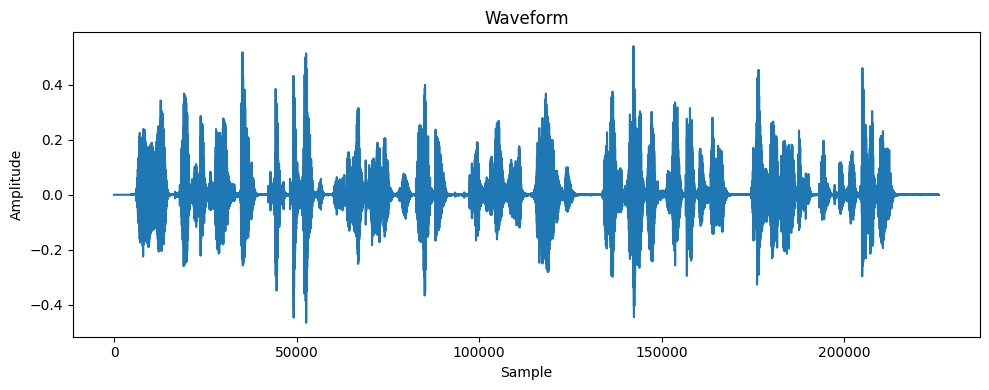

waveforms shape after preparation in recognize: (1, 1, 225963), min: -0.46981343626976013, max: 0.6228879690170288
audio_length: [225963]
Predicted output length: [1413]
input_signal shape: (1, 1, 225963), min: -0.46981343626976013, max: 0.6228879690170288
Mean before CMVN: 3.6723827179230284e-06, Std before CMVN: 0.05302887037396431
batch_size: 1, channels: 1, time: 225963, num_frames: 1413
Power spectrum shape: (201, 1413), min: 9.37555745962028e-50, max: 48201.44415322461
Mel spec shape: (80, 1413), min: 3.255157736313063e-25, max: 637.2110981929267
Mel spectrogram shape: (1, 1, 80, 1413)
Melspec NumPy: min=3.255157736313063e-25, max=637.2110981929267
Log mel spec NumPy shape: (1, 1, 80, 1413), min: -16.635532333438686, max: 6.457100995104133
After CMVN: mean=[[[[-10.6083311 ]
   [ -9.40067019]
   [ -7.29418506]
   [ -7.42404033]
   [ -5.97203699]
   [ -6.85571285]
   [ -6.98608185]
   [ -6.16904794]
   [ -6.3424424 ]
   [ -5.9092318 ]
   [ -5.83303481]
   [ -4.97812642]
   [ -5.168

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
2025-06-09 01:58:46,513 - huggingface_hub.file_download - WARNING - Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Error computing BERTScore: [Errno 28] No space left on device
Metrics:
WER: 0.000000000000000
CER: 0.000000000000000
MER: 0.000000000000000
WIL: 0.000000000000000
WIP: 1.000000000000000
RIL: 0.000000000000000
WER_torchmetrics: 0.000000000000000
CER_torchmetrics: 0.000000000000000
WIL_torchmetrics: 0.000000000000000
MER_torchmetrics: 0.000000000000000
WIP_torchmetrics: 1.000000000000000
RIL_torchmetrics: 0.000000000000000
BLEU: 1.000000000000000
BLEU_torchmetrics: 1.000000000000000
ROUGE-1: 0.944444444444444
ROUGE-2: 1.000000000000000
ROUGE-L: 1.000000000000000
Semantic Similarity: Not computed due to error
PER: Not computed due to error
METEOR: 0.999914266117970
BERTScore: Not computed due to error
Mean difference (raw): 4.340053750268545
Mean difference (after CMVN): 0.01888333640120998
Транскрипция жадного декодирования (RNN-T NumPy): мне необходимо вам рассказать следующую историю о своей жизни чем четче я говорю тем лучше результат я получу


In [19]:
!pip list

preprocessor_Rnnt_NumPy = RnntASRNumPy(
    encoder_path=NEMO_CONSTANTS.CUSTOM_ENCODER_PATH,
    decoder_joint_path=NEMO_CONSTANTS.CUSTOM_DECODER_PATH,
    vocab_path=NEMO_CONSTANTS.VOCAB_PATH,
    graphics_create=False,
    window="hann",
    center=True,
    mel_filterbank_type="complex",
)

# # Инференс RNN-T NumPy
waveform, sr = torchaudio.load(audio_path)
# Преобразование аудио в тензор и добавление размерности батча
audio_tensor = torch.tensor(waveform).unsqueeze(0)
# Длина аудиофайла
audio_len = torch.tensor([waveform.shape[0]], dtype=torch.int32)
print(f"Waveform shape: {waveform.shape}, sample rate: {sr}")
if sr != 16000:
    resampler = torchaudio.transforms.Resample(sr, 16000)
    waveform = resampler(waveform)
    print(f"Resampled waveform shape: {waveform.shape}")

plt.figure(figsize=(10, 4))
plt.plot(waveform[0].numpy())
plt.title("Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

transcriptionGD_Rnnt_NumPy, timestampsGD_Rnnt_NumPy = preprocessor_Rnnt_NumPy.recognize(
    waveforms=waveform.numpy(),
    decode_flag="greedy",
    ground_truth=ground_truth,
    clean_transcription=True
)

mel_numpy_raw = np.load("mel_spec_numpy_raw.npy")
mel_torch_raw = np.load("mel_spec_torch_raw.npy")
diff_raw = np.abs(mel_numpy_raw - mel_torch_raw)
print(f"Mean difference (raw): {np.mean(diff_raw)}")

mel_numpy_after = np.load("mel_spec_numpy_cmvn.npy")
mel_torch_after = np.load("mel_spec_torch_cmvn.npy")
diff_after = np.abs(mel_numpy_after - mel_torch_after)
print(f"Mean difference (after CMVN): {np.mean(diff_after)}")

# transcriptionBS_Rnnt_NumPy = None
# for beam_width in beam_widths:
#     for lp in length_penalties:
#         print(f"\nTesting RNN-T NumPy beam_width={beam_width}, length_penalty={lp}")
#         time.sleep(5)
#         transcriptionBS_Rnnt_NumPy, timestampsBS_Rnnt_NumPy = preprocessor_Rnnt_NumPy.recognize(
#             waveforms=waveform.numpy(),
#             decode_flag="beam",
#             beam_width=beam_width,
#             length_penalty=lp,
#             ground_truth=ground_truth,
#             clean_transcription=True
#         )
#         print(f"Транскрипция (RNN-T NumPy Beam Search, beam_width={beam_width}, length_penalty={lp}): {transcriptionBS_Rnnt_NumPy}")

print("Транскрипция жадного декодирования (RNN-T NumPy):", transcriptionGD_Rnnt_NumPy)
# print("Транскрипция декодирования по лучу (RNN-T NumPy):", transcriptionBS_Rnnt_NumPy)

In [18]:
import sys
print("Python executable:", sys.executable)
import torchaudio
print("Torchaudio imported successfully:", torchaudio.__version__)

Python executable: E:\Прога (вся)\NeuralSpecter\AUDIO_MODELS_DECRYPTION\.venv\Scripts\python.exe
Torchaudio imported successfully: 2.5.1+cpu


### 🌠 Тестирование оригинальной NVIDIA Nemo модели

#### 🌌 Librosa

In [ ]:
# --- Инициализация модели и выполнение инференса ---
model_files = {
    "encoder": NEMO_CONSTANTS.ENCODER_PATH,
    "decoder_joint": NEMO_CONSTANTS.DECODER_PATH,
    "vocab": NEMO_CONSTANTS.VOCAB_PATH
}

# Создание экземпляра модели
onnx_model = RnntASRNumPy(
    encoder_path=model_files["encoder"],
    decoder_joint_path=model_files["decoder_joint"],
    vocab_path=model_files["vocab"],
    graphics_create=True,
    window="hann",
    center=True,
    mel_filterbank_type="complex",
)

# Загрузка и обработка аудио
audio, sr = librosa.load(audio_path, 
                         sr=ConstantsRNNT.sample_rate)
print(f"Loaded audio by librosa: shape: {audio.shape}, sample rate: {sr}")

audio_tensor = torch.tensor(audio).unsqueeze(0)
audio_length = torch.tensor([audio_tensor.shape[1]], 
                            dtype=torch.int32)

# Извлечение признаков
features, features_len = onnx_model.extract_features(audio_tensor, 
                                                     audio_length)
features_np = features.numpy().astype(np.float32)
features_len_np = features_len.numpy().astype(np.int64)
print(f"Features shape: {features_np.shape}")
print(f"Features length: {features_len_np}")
print("Features shape:", features_np.shape)
print("Features dtype:", features_np.dtype)
print("Features (Original RNNT model - Librosa: первые несколько значений):", features_np[0, :, :5])

# Получение выходов энкодера
encoder_out, encoder_out_len = onnx_model._encode(features_np, 
                                                  features_len_np)
print(f"Encoder output shape: {encoder_out.shape}")
print(f"Encoder output length: {encoder_out_len}")

# Декодирование аудио в текст
transcription, timestamps = onnx_model.recognize(audio, 
                                                 decode_flag="greedy",
                                                 ground_truth=ground_truth,
                                                 clean_transcription=True)
print("Transcription:", transcription)

#### 🌌 Torchaudio

In [ ]:
# Загрузка аудио с помощью torchaudio
audio, sr = torchaudio.load(audio_path)
print(f"Loaded audio by torchaudio: shape: {audio.shape}, sample rate: {sr}")

# Если частота дискретизации не соответствует 16000 Гц, преобразуем
if sr != ConstantsRNNT.sample_rate:
    resampler = torchaudio.transforms.Resample(sr, ConstantsRNNT.sample_rate)
    audio = resampler(audio)

# Если аудио стерео, берём первый канал
if audio.shape[0] > 1:
    audio = audio[0:1, :]

audio_tensor = audio
audio_length = torch.tensor([audio_tensor.shape[1]], 
                            dtype=torch.int32)

# Извлечение признаков
features, features_len = onnx_model.extract_features(audio_tensor, audio_length)
features_np = features.numpy().astype(np.float32)
features_len_np = features_len.numpy().astype(np.int64)
print(f"Features shape: {features_np.shape}")
print(f"Features length: {features_len_np}")
print("Features shape:", features_np.shape)
print("Features dtype:", features_np.dtype)
print("Features (Original RNNT model - Torchaudio: первые несколько значений):", features_np[0, :, :5])

# Получение выходов энкодера
encoder_out, encoder_out_len = onnx_model._encode(features_np, features_len_np)
print(f"Encoder output shape: {encoder_out.shape}")
print(f"Encoder output length: {encoder_out_len}")

# Декодирование аудио в текст
transcription, timestamps = onnx_model.recognize(audio.numpy(), 
                                                 decode_flag="greedy",
                                                 ground_truth=ground_truth,
                                                 clean_transcription=True)
print("Transcription:", transcription)

#### 🌌Soundfile

In [ ]:
# Загрузка аудио с помощью soundfile
audio_data, original_sample_rate = sf.read(audio_path, dtype='float32')
print(f"Loaded audio shape: {audio_data.shape}, sample rate: {original_sample_rate}")

# Убеждаемся, что аудио в правильном формате (samples,) или (samples, channels)
if audio_data.ndim == 1:
    # Моно аудио
    audio_mono = audio_data
    print("Audio is already mono")
elif audio_data.ndim == 2:
    # Стерео или многоканальное аудио
    if audio_data.shape[1] > 1:
        # Берем среднее по каналам для преобразования в моно
        audio_mono = np.mean(audio_data, axis=1)  # Исправлено с audio_data[0] на np.mean
        print(f"Converted from {audio_data.shape[1]} channels to mono by averaging")
    else:
        # Одноканальное аудио в формате (samples, 1)
        audio_mono = audio_data[:, 0]
        print("Extracted single channel from 2D array")
else:
    raise ValueError(f"Unexpected audio shape: {audio_data.shape}")

# Ресэмплинг если необходимо
if original_sample_rate != ConstantsRNNT.sample_rate:
    print(f"Resampling from {original_sample_rate} Hz to {ConstantsRNNT.sample_rate} Hz")
    audio_mono = resample_audio(audio_mono, original_sample_rate, ConstantsRNNT.sample_rate)

print(f"Final audio shape: {audio_mono.shape}")
print(f"Audio range: min={audio_mono.min():.4f}, max={audio_mono.max():.4f}")

# Убеждаемся, что аудио в правильном типе данных
if audio_mono.dtype != np.float32:
    audio_mono = audio_mono.astype(np.float32)

# Создание тензоров с правильными типами данных
audio_tensor = torch.from_numpy(audio_mono).float().unsqueeze(0)
audio_length = torch.tensor([audio_tensor.shape[1]], dtype=torch.long)

print(f"Audio tensor shape: {audio_tensor.shape}")
print(f"Audio length: {audio_length}")

# Извлечение признаков
features, features_len = onnx_model.extract_features(audio_tensor, audio_length)
features_np = features.numpy().astype(np.float32)
features_len_np = features_len.numpy().astype(np.int64)
print(f"Features shape: {features_np.shape}")
print(f"Features length: {features_len_np}")
print("Features shape:", features_np.shape)
print("Features dtype:", features_np.dtype)
print("Features (Original RNNT model - Soundfile: первые несколько значений):", features_np[0, :, :5])

# Получение выходов энкодера
encoder_out, encoder_out_len = onnx_model._encode(features_np, features_len_np)
print(f"Encoder output shape: {encoder_out.shape}")
print(f"Encoder output length: {encoder_out_len}")

# Декодирование аудио в текст
transcription, timestamps = onnx_model.recognize(audio_mono, decode_flag="greedy", ground_truth=ground_truth, clean_transcription=True)
print("Transcription:", transcription)

### 🏗️ Сравнение результатов оригинальной и кастомной модели

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as rt
from datetime import datetime
import torchaudio as T
from nemo.collections.asr.models import EncDecHybridRNNTCTCBPEModel
from dataclasses import dataclass
import torch
import pandas as pd
from datasets import load_dataset
from tqdm.notebook import tqdm
from itertools import islice
from timeit import default_timer as timer
import jiwer

# Загрузка аудио
audio_path = "audio_files/20250404_174500.wav"
waveform, sr = T.load(audio_path)
print(f"Loaded waveform shape: {waveform.shape}, sample rate: {sr}")

# Конвертация стерео в моно и ресэмплинг
if waveform.shape[0] > 1:  # Стерео
    waveform = torch.mean(waveform, dim=0, keepdim=True)
if sr != ConstantsRNNT.sample_rate:
    resampler = T.transforms.Resample(sr, ConstantsRNNT.sample_rate)
    waveform = resampler(waveform)
print(f"Resampled waveform shape: {waveform.shape}")

# Преобразование в NumPy для совместимости
waveform_np = waveform.squeeze(0).numpy().astype(np.float32)  # Убираем размерность батча
waveform_np = waveform_np[np.newaxis, np.newaxis, :]  # [1, 1, time] — корректная форма для одного канала
print(f"waveform_np shape after preparation: {waveform_np.shape}")

# Длина аудио
audio_length_np = np.array([waveform_np.shape[-1]], dtype=np.int64)
audio_length_torch = torch.tensor([waveform_np.shape[-1]], dtype=torch.long)

print(f"Audio tensor shape (NumPy): {waveform_np.shape}, audio_length: {audio_length_np}")
print(f"Audio tensor shape (Torch): {waveform.shape}, audio_length: {audio_length_torch}")

# Инициализация моделей (предполагается, что классы определены)
custom_model = RnntASRNumPy(
    encoder_path=NEMO_CONSTANTS.CUSTOM_ENCODER_PATH,
    decoder_joint_path=NEMO_CONSTANTS.CUSTOM_DECODER_PATH,
    vocab_path=NEMO_CONSTANTS.VOCAB_PATH,
    graphics_create=True,
    window="hann",
    center=True,
    mel_filterbank_type="complex"
)

original_model = RnntASRPyTorchOriginal(
    encoder_path=NEMO_CONSTANTS.CUSTOM_ENCODER_PATH,
    decoder_joint_path=NEMO_CONSTANTS.CUSTOM_DECODER_PATH,
    vocab_path=NEMO_CONSTANTS.VOCAB_PATH,
    graphics_create=True
)

# Извлечение признаков с отладкой
print("Extracting features with custom NumPy model...")
custom_features, custom_features_len = custom_model.extract_features(waveform_np, audio_length_np)
print("Custom NumPy Preprocessor:")
print(f"Features shape: {custom_features.shape}")
print(f"Features length: {custom_features_len}")

print("Extracting features with original PyTorch model...")
original_features, original_features_len = original_model.extract_features(
    torch.from_numpy(waveform_np.squeeze(0).squeeze(0)).float().unsqueeze(0), audio_length_torch
)
original_features_np = original_features.detach().cpu().numpy().astype(np.float32)
original_features_len_np = original_features_len.detach().cpu().numpy().astype(np.int64)
print("Original PyTorch Preprocessor:")
print(f"Features shape: {original_features_np.shape}")
print(f"Features length: {original_features_len_np}")

# Сравнение признаков
shape_match = custom_features.shape == original_features_np.shape
value_match = np.allclose(custom_features, original_features_np, rtol=1e-5, atol=1e-8)
print(f"Feature shapes match: {shape_match}")
print(f"Feature values match (within tolerance): {value_match}")
if not shape_match or not value_match:
    print(f"Max difference: {np.max(np.abs(custom_features - original_features_np))}")

# Сохранение для визуальной проверки
np.save("custom_features_numpy.npy", custom_features)
np.save("original_features_pytorch.npy", original_features_np)

# Анализ различий между mel_spec до и после CMVN
mel_numpy_raw = np.load("mel_spec_numpy_raw.npy")
mel_torch_raw = np.load("mel_spec_torch_raw.npy")
diff_raw = np.abs(mel_numpy_raw - mel_torch_raw)
print(f"Mean difference (raw): {np.mean(diff_raw)}")

mel_numpy_after = np.load("mel_spec_numpy_cmvn.npy")
mel_torch_after = np.load("mel_spec_torch_cmvn.npy")
diff_after = np.abs(mel_numpy_after - mel_torch_after)
print(f"Mean difference (after CMVN): {np.mean(diff_after)}")

# Полный пайплайн
ground_truth = "мне необходимо вам рассказать следующую историю о своей жизни чем четче я говорю тем лучше результат я получу"
print("Running recognition with custom NumPy model...")
custom_transcription, custom_timestamps = custom_model.recognize(
    waveforms=waveform_np,
    decode_flag="greedy",
    ground_truth=ground_truth,
    max_steps=3000,
    min_tokens=15,
    state_init="zero",
    clean_transcription=True
)
print("Custom NumPy Model Transcription:", custom_transcription)
print("Custom NumPy Timestamps:", custom_timestamps)

print("Running recognition with original PyTorch model...")
original_transcription, original_timestamps = original_model.recognize(
    waveforms=waveform_np.squeeze(0).squeeze(0),
    decode_flag="greedy",
    ground_truth=ground_truth,
    max_steps=3000,
    min_tokens=15,
    state_init="zero",
    clean_transcription=True
)
print("Original PyTorch Model Transcription:", original_transcription)
print("Original PyTorch Timestamps:", original_timestamps)

# Сравнение транскрипций
transcription_match = custom_transcription == original_transcription
print(f"Transcriptions match: {transcription_match}")

# Сравнение токенов (извлечение через декодирование)
custom_hyp, _, custom_decoded_timestamps = custom_model.decode_rnnt_greedy_improved(
    custom_model._encode(custom_features, custom_features_len)[0],
    ground_truth,
    state_init="zero",
    clean_transcription=True
)
original_hyp, _, original_decoded_timestamps = original_model.decode_rnnt_greedy_improved(
    original_model._encode(original_features_np, original_features_len_np)[0],
    ground_truth,
    state_init="zero",
    clean_transcription=True
)
custom_tokens = [custom_model.vocab[idx] for idx in custom_model.decode_rnnt_greedy_improved(
    custom_model._encode(custom_features, custom_features_len)[0],
    ground_truth,
    state_init="zero",
    clean_transcription=True
)[2] if idx < len(custom_model.vocab)]
original_tokens = [original_model.vocab[idx] for idx in original_model.decode_rnnt_greedy_improved(
    original_model._encode(original_features_np, original_features_len_np)[0],
    ground_truth,
    state_init="zero",
    clean_transcription=True
)[2] if idx < len(original_model.vocab)]
tokens_match = custom_tokens == original_tokens
print(f"Tokens match: {tokens_match}")
if not tokens_match:
    print("Custom tokens:", custom_tokens)
    print("Original tokens:", original_tokens)

# Сравнение таймштампов
timestamps_match = custom_timestamps == original_timestamps
print(f"Timestamps match: {timestamps_match}")
if not timestamps_match:
    print("Custom timestamps:", custom_timestamps)
    print("Original timestamps:", original_timestamps)

# Визуализация
plt.figure(figsize=(10, 4))
plt.imshow(custom_features[0], aspect="auto", origin="lower", interpolation="nearest")
plt.colorbar(label="Normalized Log Mel Energy")
plt.title("Custom NumPy Preprocessor Mel-Spectrogram")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency Bins")
plt.tight_layout()
plt.savefig("custom_numpy_mel_spectrogram.png")
plt.close()

plt.figure(figsize=(10, 4))
plt.imshow(original_features_np[0], aspect="auto", origin="lower", interpolation="nearest")
plt.colorbar(label="Normalized Log Mel Energy")
plt.title("Original PyTorch Preprocessor Mel-Spectrogram")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency Bins")
plt.tight_layout()
plt.savefig("original_pytorch_mel_spectrogram.png")
plt.close()

# Автотесты
!pip install "datasets[audio]>=3" jiwer pandas jinja2 tqdm onnx_asr[gpu,hub]

from onnx_asr import load_model

cer_transform = jiwer.Compose(
    [
        jiwer.ToLowerCase(),
        jiwer.SubstituteRegexes({"ё": "е"}),
        jiwer.RemovePunctuation(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ReduceToListOfListOfChars(),
    ]
)

wer_transform = jiwer.Compose(
    [
        jiwer.ToLowerCase(),
        jiwer.SubstituteRegexes({"ё": "е"}),
        jiwer.RemovePunctuation(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ReduceToListOfListOfWords(),
    ]
)

def calc_cer(transcript, result):
    metrics_cer = jiwer.process_characters(transcript, result, cer_transform, cer_transform)
    return {
        "char_errors": metrics_cer.substitutions + metrics_cer.deletions + metrics_cer.insertions,
        "char_count": len(metrics_cer.references[0]),
    }

def calc_wer(transcript, result):
    metrics_wer = jiwer.process_words(transcript, result, wer_transform, wer_transform)
    return {
        "word_errors": metrics_wer.substitutions + metrics_wer.deletions + metrics_wer.insertions,
        "word_count": len(metrics_wer.references[0]),
    }

def agg_metrics(group):
    return pd.Series(
        {
            "N": len(group),
            "CER": group.char_errors.sum() / group.char_count.sum(),
            "WER": group.word_errors.sum() / group.word_count.sum(),
            "RTFx": group.duration.sum() / group.asr_time.sum(),
        }
    )

def run_test(model_name, providers=None, quantization=None):
    model = load_model(model_name, quantization=quantization, providers=providers)

    for row in tqdm(ds[:100]):
        model.recognize(row["audio"]["array"], language="ru", sample_rate=row["audio"]["sampling_rate"])

    for row in tqdm(ds):
        start = timer()
        waveform = row["audio"]["array"]
        sample_rate = row["audio"]["sampling_rate"]
        result = model.recognize(waveform, language="ru", sample_rate=sample_rate)
        yield {
            "model": model_name,
            "providers": str(providers),
            "quantization": str(quantization),
            "result": result,
            "text": row["text"],
            "duration": waveform.shape[0] / sample_rate,
            "asr_time": timer() - start,
        }

n = None
ds = list(islice(load_dataset("istupakov/russian_librispeech", split="test", streaming=True), n))
providers = ["CUDAExecutionProvider"]

df = pd.DataFrame(
    [
        *run_test("gigaam-v2-ctc", providers),
        *run_test("gigaam-v2-rnnt", providers),
        *run_test("nemo-fastconformer-ru-ctc", providers),
        *run_test("nemo-fastconformer-ru-rnnt", providers),
        *run_test("alphacep/vosk-model-ru", providers),
        *run_test("alphacep/vosk-model-small-ru", providers),
        *run_test("whisper-base", providers),
        *run_test("onnx-community/whisper-large-v3-turbo", providers, "fp16"),
    ]
)

df["result"] = df["result"].fillna("")

tqdm.pandas(desc="calc_cer")
df = df.join(df.progress_apply(lambda row: pd.Series(calc_cer(row.text, row.result)), axis=1))

tqdm.pandas(desc="calc_wer")
df = df.join(df.progress_apply(lambda row: pd.Series(calc_wer(row.text, row.result)), axis=1))

with pd.option_context("display.max_rows", None):
    display(
        df.groupby(["model", "providers", "quantization"], sort=False)
        .apply(agg_metrics, include_groups=False)
        .style.format(formatter="{:0.0f}".format, subset=["N"])
        .format(formatter="{:,.2%}".format, subset=["CER", "WER"])
        .format(formatter="{:0.1f}".format, subset=["RTFx"])
    )

Loaded waveform shape: torch.Size([2, 677888]), sample rate: 48000
Resampled waveform shape: torch.Size([1, 225963])
waveform_np shape after preparation: (1, 1, 225963)
Audio tensor shape (NumPy): (1, 1, 225963), audio_length: [225963]
Audio tensor shape (Torch): torch.Size([1, 225963]), audio_length: tensor([225963])
Loaded vocabulary with 1025 tokens
First 10 tokens: ['<unk>', '▁.', '▁,', 'е', 'а', '▁в', 'с', '▁с', '▁на', '▁?']
Last 10 tokens: ['Х', 'Ц', 'Щ', 'Ж', 'Э', '?', ',', '.', 'Ь', '<blk>']
Blank index: 1024 ('<blk>')
UNK index: 0 ('<unk>')
Pad index: 1024 ('<blk>')
Max vocab index: 1024
Decoder joint inputs:
Name: encoder_outputs, Shape: ['encoder_outputs_dynamic_axes_1', 512, 'encoder_outputs_dynamic_axes_2'], Type: tensor(float)
Name: targets, Shape: ['targets_dynamic_axes_1', 'targets_dynamic_axes_2'], Type: tensor(int32)
Name: target_length, Shape: ['target_length_dynamic_axes_1'], Type: tensor(int32)
Name: input_states_1, Shape: [1, 'input_states_1_dynamic_axes_1', 640],

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
2025-06-09 01:59:08,379 - huggingface_hub.file_download - WARNING - Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


OSError: [Errno 28] No space left on device